<h1 style='color:#426d84; font-size:30px; font-weight:bold;'>📈 DSO3 — Regional Real Estate Price Trend & Forecasting</h1>
<p style='font-size:15px;'>Pipeline SARIMAX complet — <b>BCT (national) + INS (par gouvernorat) + Tayara (scraped 2024–2026)</b></p>
<hr>
<table style='font-size:13px'>
<tr><td><b>Sources</b></td><td>BCT IPIM national · INS IPIM par gouvernorat · Tayara annonces scrapées</td></tr>
<tr><td><b>Période</b></td><td>Jan 2015 → Fév 2026 (~132 points mensuels)</td></tr>
<tr><td><b>Gouvernorats</b></td><td>Tunis, Ariana, Ben Arous, Nabeul, Sousse, Sfax, Bizerte, Manouba, Monastir, Médenine</td></tr>
<tr><td><b>Modèle</b></td><td>SARIMAX adaptatif — ordre réduit pour séries courtes, complet pour séries longues</td></tr>


## 📦 1 — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

PALETTE = ['#426d84','#5c8399','#7b98a6','#87BAC3','#2c3e50','#E8593C','#e8a23c','#3ce87a']
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13, 'axes.labelsize': 11})

TOP_GOVS = ['Tunis', 'Ariana', 'Ben Arous', 'Nabeul', 'Sousse', 'Sfax',
            'Bizerte', 'Manouba', 'Monastir', 'Médenine']

MAPE_SEUIL_BON   = 20
MAPE_SEUIL_MOYEN = 35

print('✅ Imports OK')

✅ Imports OK


## 📂 2 — Chargement des 3 sources de données

In [2]:
# ── Source 1 : BCT — Index national IPIM (2015–2024) ──────────────────────
bct = pd.read_csv('bct_ipim_data.csv', parse_dates=['date'])
bct = bct.sort_values('date').reset_index(drop=True)
print(f'✅ BCT  : {len(bct)} points | {bct["date"].min().date()} → {bct["date"].max().date()}')

# ── Source 2 : INS — Index par gouvernorat (2015–2024) ────────────────────
ins = pd.read_csv('ins_ipim_by_governorate.csv', parse_dates=['date'])
ins = ins.sort_values(['governorate','date']).reset_index(drop=True)
print(f'✅ INS  : {len(ins)} points | {ins["governorate"].nunique()} gouvernorats | '
      f'{ins["date"].min().date()} → {ins["date"].max().date()}')
print(f'   Gouvernorats: {sorted(ins["governorate"].unique().tolist())}')

# ── Source 3 : Dataset scrapé (Tayara dates via ObjectID) ─────────────────
df = pd.read_csv('final_dataset_with_dates.csv', low_memory=False)
print(f'✅ CSV  : {len(df):,} annonces | {df["source"].nunique()} sources')

✅ BCT  : 120 points | 2015-01-01 → 2024-12-01
✅ INS  : 1200 points | 10 gouvernorats | 2015-01-01 → 2024-12-01
   Gouvernorats: ['Ariana', 'Ben Arous', 'Bizerte', 'Manouba', 'Monastir', 'Médenine', 'Nabeul', 'Sfax', 'Sousse', 'Tunis']
✅ CSV  : 31,257 annonces | 14 sources


## 🔵 3 — Extraction des dates Tayara (MongoDB ObjectID)

Les IDs Tayara sont des **MongoDB ObjectIDs** — les 4 premiers octets encodent un **timestamp Unix exact**.

`date = datetime.fromtimestamp(int(listing_id[:8], 16))`

In [3]:
def objectid_to_date(oid):
    try:
        ts = int(str(oid)[:8], 16)
        dt = datetime.fromtimestamp(ts)
        return dt if 2022 <= dt.year <= 2027 else None
    except:
        return None

tayara = df[df['source'] == 'tayara'].copy()
tayara['date_posted'] = tayara['listing_id'].apply(objectid_to_date)
tayara_valid = tayara[tayara['date_posted'].notna()].copy()
tayara_valid['gov_clean'] = (
    tayara_valid['governorate']
    .str.strip()
    .str.replace('-', ' ')
    .str.title()
)
tayara_valid['price'] = pd.to_numeric(tayara_valid['price'], errors='coerce')

## 🔵 4 — Prix mensuels médians Tayara + Lissage

**Correction :** Ajout d'un lissage par moyenne mobile (fenêtre 3 mois) sur les prix Tayara
pour réduire la volatilité due aux faibles effectifs mensuels.

In [4]:
# Nettoyage outliers (percentile 5–95 par gouvernorat)
def remove_outliers(group):
    q5  = group['price'].quantile(0.05)
    q95 = group['price'].quantile(0.95)
    return group[(group['price'] >= q5) & (group['price'] <= q95)]

tayara_clean = tayara_valid.groupby('gov_clean', group_keys=False).apply(remove_outliers)
tayara_clean = tayara_clean[tayara_clean['price'] > 10000]
tayara_clean['month'] = tayara_clean['date_posted'].dt.to_period('M')

# Médiane mensuelle par gouvernorat
monthly_tayara = (
    tayara_clean
    .groupby(['gov_clean', 'month'])['price']
    .agg(price_median='median', n_listings='count')
    .reset_index()
)
monthly_tayara['month_dt'] = monthly_tayara['month'].dt.to_timestamp()

# ── CORRECTION v2 : Lissage robuste par moyenne mobile ────────────────────
# Atténue les pics aberrants dus aux faibles effectifs (ex: 1-2 annonces/mois)
def smooth_prices(group):
    group = group.sort_values('month_dt').copy()
    # Lissage pondéré par nombre d'annonces — mois avec peu d'annonces pèsent moins
    group['price_smooth'] = group['price_median'].rolling(
        window=3, center=True, min_periods=1
    ).mean()
    return group

monthly_tayara = monthly_tayara.groupby('gov_clean', group_keys=False).apply(smooth_prices)
monthly_tayara['price_final'] = np.where(
    monthly_tayara['n_listings'] >= 3,
    monthly_tayara['price_median'],    # Garder médiane brute si ≥3 annonces
    monthly_tayara['price_smooth']     # Sinon utiliser version lissée
)

print('Points Tayara par gouvernorat:')
summary = monthly_tayara.groupby('gov_clean').agg(
    n_mois=('month_dt', 'count'),
    n_annonces_total=('n_listings', 'sum'),
    prix_moy=('price_final', 'mean')
).sort_values('n_mois', ascending=False)
print(summary.to_string())

Points Tayara par gouvernorat:
           n_mois  n_annonces_total       prix_moy
gov_clean                                         
Nabeul         19               404  327723.394737
Sousse         17               347  375362.745098
Tunis          17               675  466847.029412
Mahdia         16                65  303350.000000
Ben Arous      15               295  340183.000000
Ariana         13               452  404909.641026
Monastir       11                44  259560.606061
Bizerte        11                75  363636.318182
Sfax           10                78  437833.333333
Manouba         7                35  402190.476190
Médenine        5                30  444166.666667
Jendouba        3                 6  650000.000000
Gabès           3                 7  260000.000000
Kairouan        2                 4  282500.000000
Béja            2                 2  180000.000000
Gafsa           1                 2  162500.000000
Le Kef          1                 2   55000.000000


## 🟡 5 — Construction de la série complète (INS + Tayara)

In [5]:
def build_complete_series(gov):

    # ── INS ─────────────────────────────
    ins_gov = ins[ins['governorate'] == gov][['date', 'ins_ipim_index']].copy()
    
    if ins_gov.empty:
        return None

    ins_gov = ins_gov.sort_values('date').set_index('date')

    # ── Tayara ──────────────────────────
    tay_gov = monthly_tayara[monthly_tayara['gov_clean'] == gov][
        ['month_dt', 'price_final', 'n_listings']
    ].copy()

    if tay_gov.empty:
        return None

    tay_gov = tay_gov.rename(columns={'price_final': 'price_median'})
    tay_gov = tay_gov.sort_values('month_dt').set_index('month_dt')

    # sécurité minimale
    if len(tay_gov) < 3:
        return None

    # ── Ratio INS → TND ─────────────────
    tay_early = tay_gov.head(3)

    ratios = []
    for dt_tay, row_tay in tay_early.iterrows():
        ins_matches = ins_gov[ins_gov.index <= dt_tay]

        if not ins_matches.empty:
            ins_val = ins_matches.iloc[-1]['ins_ipim_index']

            if pd.notna(ins_val) and ins_val > 0 and pd.notna(row_tay['price_median']):
                ratios.append(row_tay['price_median'] / ins_val)

    # sécurité ratios
    if len(ratios) < 2:
        return None

    tnd_per_ins_point = np.median(ratios)

    # ── Historique INS → prix ───────────
    hist = ins_gov.copy()
    hist['price_median'] = hist['ins_ipim_index'] * tnd_per_ins_point
    hist['ins_index'] = hist['ins_ipim_index']
    hist['source_data'] = 'INS_officiel'
    hist = hist[['price_median', 'ins_index', 'source_data']]

    # ── Tayara ──────────────────────────
    tay_gov['ins_index'] = np.nan
    tay_gov['source_data'] = 'Tayara_scraped'
    tay_gov = tay_gov[['price_median', 'ins_index', 'source_data']]

    # ── Fusion ──────────────────────────
    combined = pd.concat([hist, tay_gov])

    # supprimer doublons (garder Tayara en priorité)
    combined = combined[~combined.index.duplicated(keep='last')]

    # fréquence mensuelle
    combined = combined.sort_index().asfreq('MS')

    # ── Interpolation ───────────────────
    combined['price_median'] = combined['price_median'].interpolate()
    combined['ins_index'] = combined['ins_index'].interpolate()

    # supprimer lignes encore vides
    combined = combined.dropna()

    # sécurité finale
    if combined.empty or len(combined) < 6:
        return None

    # ── LOG (IMPORTANT pour modèle) ─────
    combined['price_median'] = combined['price_median'].clip(lower=1)
    combined['log_price'] = np.log(combined['price_median'])

    return combined

In [6]:
# ── Construction de all_series pour tous les gouvernorats ─────────────────
print('=== Construction des séries complètes (INS + Tayara) ===\n')

all_series = {}
for gov in TOP_GOVS:
    series = build_complete_series(gov)
    if series is not None:
        all_series[gov] = series
        n_ins    = int((series['source_data'] == 'INS_officiel').sum())
        n_tay    = int((series['source_data'] == 'Tayara_scraped').sum())
        n_total  = len(series)
        last_p   = series['price_median'].iloc[-1]
        print(f'  ✅ {gov:12s}: {n_total:3d} pts total '
              f'({n_ins} INS + {n_tay} Tayara) | '
              f'Dernier prix: {last_p:,.0f} TND')
    else:
        print(f'  ❌ {gov:12s}: données insuffisantes — ignoré')

print(f'\n✅ {len(all_series)}/{len(TOP_GOVS)} gouvernorats construits avec succès')
print(f'   Gouvernorats retenus : {list(all_series.keys())}')


=== Construction des séries complètes (INS + Tayara) ===

  ✅ Tunis       : 134 pts total (117 INS + 17 Tayara) | Dernier prix: 300,000 TND
  ✅ Ariana      : 133 pts total (120 INS + 13 Tayara) | Dernier prix: 315,000 TND
  ✅ Ben Arous   : 131 pts total (116 INS + 15 Tayara) | Dernier prix: 230,000 TND
  ✅ Nabeul      : 134 pts total (115 INS + 19 Tayara) | Dernier prix: 310,000 TND
  ✅ Sousse      : 134 pts total (117 INS + 17 Tayara) | Dernier prix: 295,000 TND
  ✅ Sfax        : 130 pts total (120 INS + 10 Tayara) | Dernier prix: 142,500 TND
  ✅ Bizerte     : 131 pts total (120 INS + 11 Tayara) | Dernier prix: 290,000 TND
  ✅ Manouba     : 127 pts total (120 INS + 7 Tayara) | Dernier prix: 304,500 TND
  ✅ Monastir    : 131 pts total (120 INS + 11 Tayara) | Dernier prix: 237,500 TND
  ✅ Médenine    : 125 pts total (120 INS + 5 Tayara) | Dernier prix: 450,000 TND

✅ 10/10 gouvernorats construits avec succès
   Gouvernorats retenus : ['Tunis', 'Ariana', 'Ben Arous', 'Nabeul', 'Sousse', 

## 📊 6 — Visualisation des séries complètes

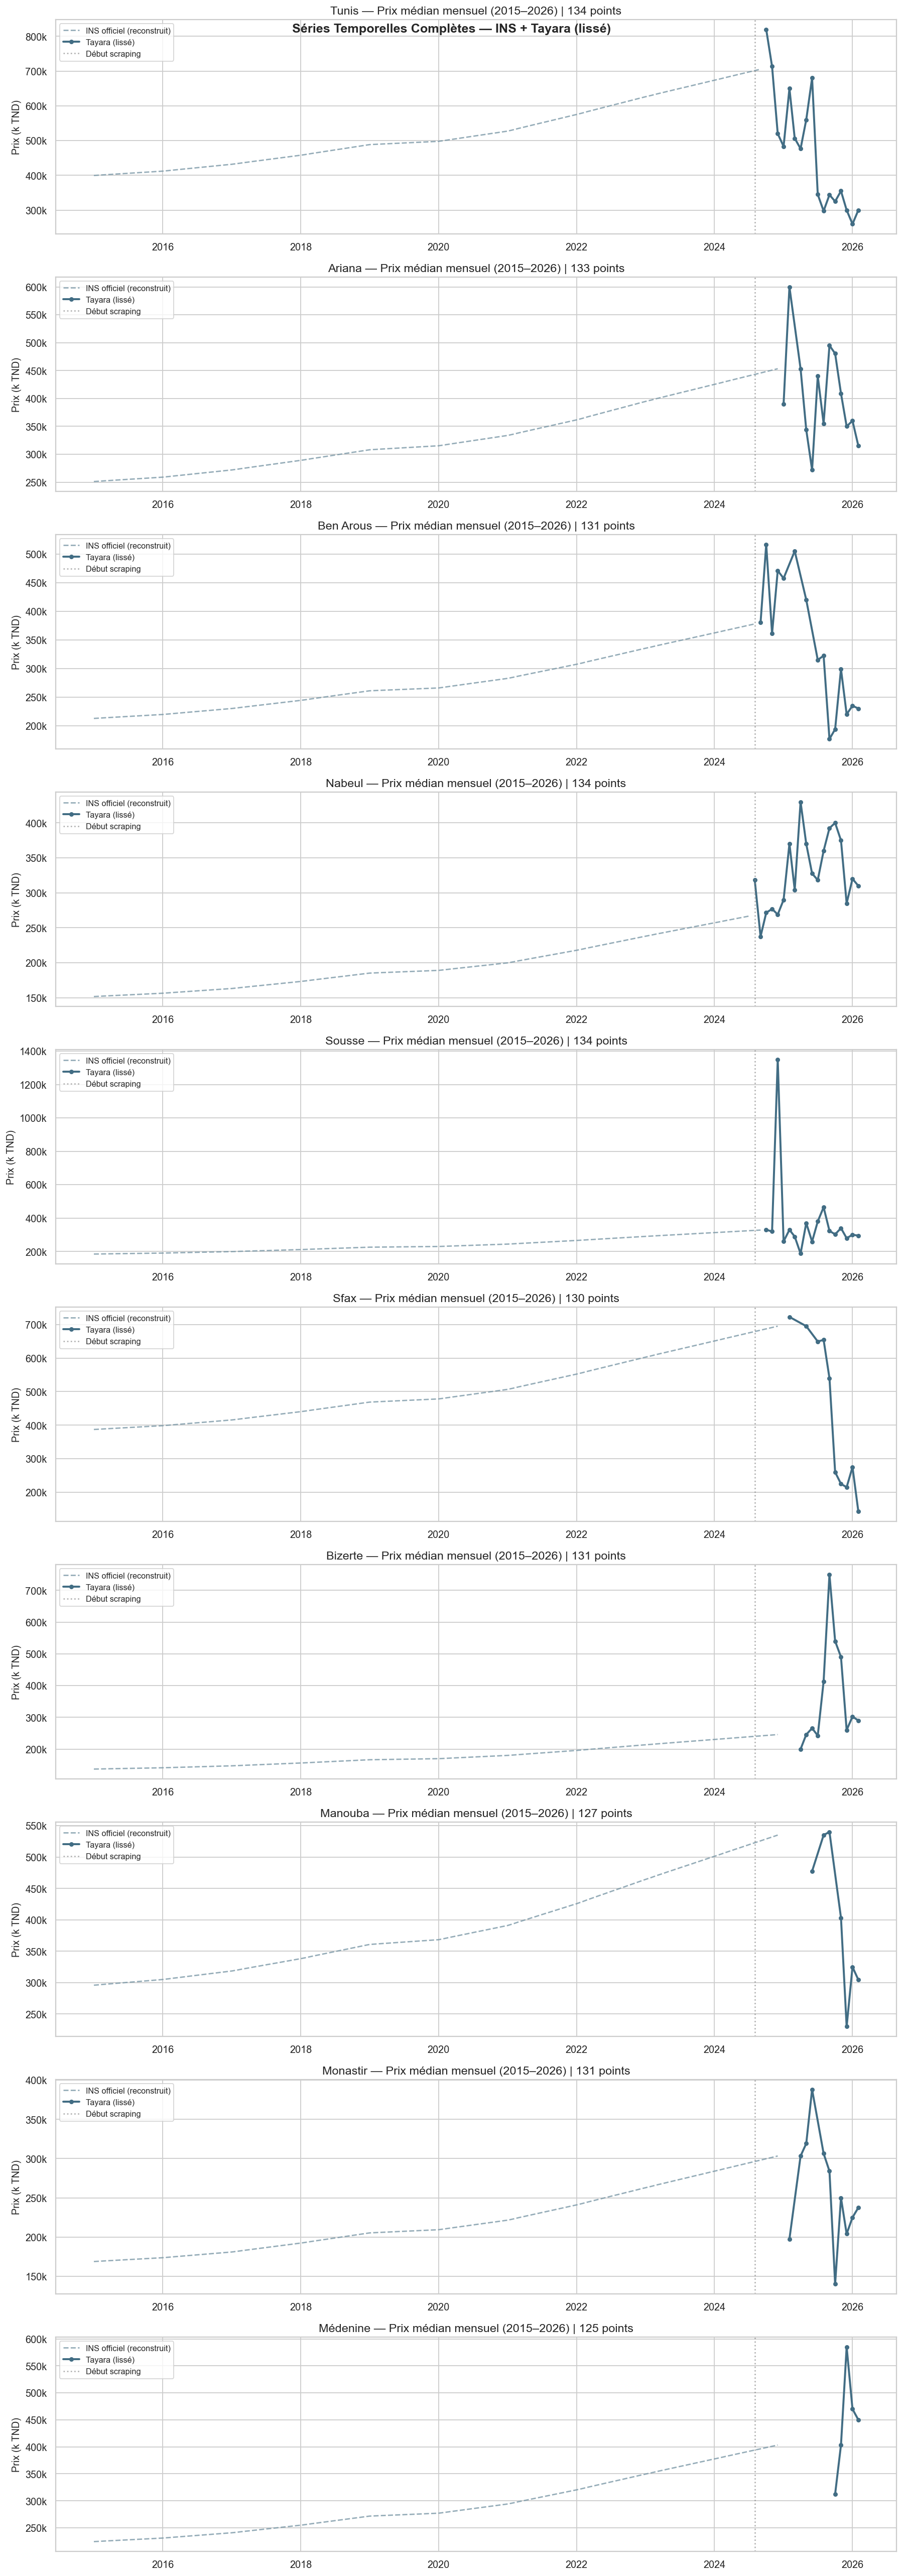

In [7]:
fig, axes = plt.subplots(len(all_series), 1, figsize=(14, 4*len(all_series)))
if len(all_series) == 1:
    axes = [axes]

for i, (gov, series) in enumerate(all_series.items()):
    ax = axes[i]
    ins_part    = series[series['source_data'] == 'INS_officiel']
    tayara_part = series[series['source_data'] == 'Tayara_scraped']

    ax.plot(ins_part.index, ins_part['price_median']/1000,
            color=PALETTE[2], linewidth=1.5, label='INS officiel (reconstruit)', linestyle='--', alpha=0.8)
    ax.plot(tayara_part.index, tayara_part['price_median']/1000,
            color=PALETTE[0], linewidth=2.2, marker='o', markersize=4, label='Tayara (lissé)')
    ax.axvline(pd.Timestamp('2024-08-01'), color='gray', linestyle=':', alpha=0.6, label='Début scraping')
    ax.set_title(f'{gov} — Prix médian mensuel (2015–2026) | {len(series)} points')
    ax.set_ylabel('Prix (k TND)')
    ax.legend(fontsize=9, loc='upper left')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}k'))

plt.suptitle('Séries Temporelles Complètes — INS + Tayara (lissé)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('series_completes_par_gouvernorat.png', bbox_inches='tight', dpi=130)
plt.show()

## 🔬 7 — Test de Stationnarité (ADF)

In [8]:
def adf_test(series, label):
    result = adfuller(series.dropna())
    p = result[1]
    stationary = p < 0.05
    status = '✅ STATIONNAIRE' if stationary else '❌ NON-STATIONNAIRE'
    print(f'  {label}: p-value={p:.4f} → {status}')
    return stationary

print('=== ADF Test — Série originale ===')
for gov, series in all_series.items():
    adf_test(series['price_median'], gov)

print('\n=== ADF Test — 1ère différence (d=1) ===')
for gov, series in all_series.items():
    adf_test(series['price_median'].diff().dropna(), f'{gov} (diff)')

=== ADF Test — Série originale ===
  Tunis: p-value=0.0602 → ❌ NON-STATIONNAIRE
  Ariana: p-value=0.7256 → ❌ NON-STATIONNAIRE
  Ben Arous: p-value=1.0000 → ❌ NON-STATIONNAIRE
  Nabeul: p-value=1.0000 → ❌ NON-STATIONNAIRE
  Sousse: p-value=0.4549 → ❌ NON-STATIONNAIRE
  Sfax: p-value=0.3312 → ❌ NON-STATIONNAIRE
  Bizerte: p-value=0.9986 → ❌ NON-STATIONNAIRE
  Manouba: p-value=0.1394 → ❌ NON-STATIONNAIRE
  Monastir: p-value=0.0078 → ✅ STATIONNAIRE
  Médenine: p-value=0.6745 → ❌ NON-STATIONNAIRE

=== ADF Test — 1ère différence (d=1) ===
  Tunis (diff): p-value=0.0000 → ✅ STATIONNAIRE
  Ariana (diff): p-value=0.0030 → ✅ STATIONNAIRE
  Ben Arous (diff): p-value=0.9548 → ❌ NON-STATIONNAIRE
  Nabeul (diff): p-value=0.9765 → ❌ NON-STATIONNAIRE
  Sousse (diff): p-value=0.0000 → ✅ STATIONNAIRE
  Sfax (diff): p-value=0.5187 → ❌ NON-STATIONNAIRE
  Bizerte (diff): p-value=0.9968 → ❌ NON-STATIONNAIRE
  Manouba (diff): p-value=0.9709 → ❌ NON-STATIONNAIRE
  Monastir (diff): p-value=0.4174 → ❌ NON-STATI

## 📊 8 — ACF / PACF — Choix des ordres SARIMAX

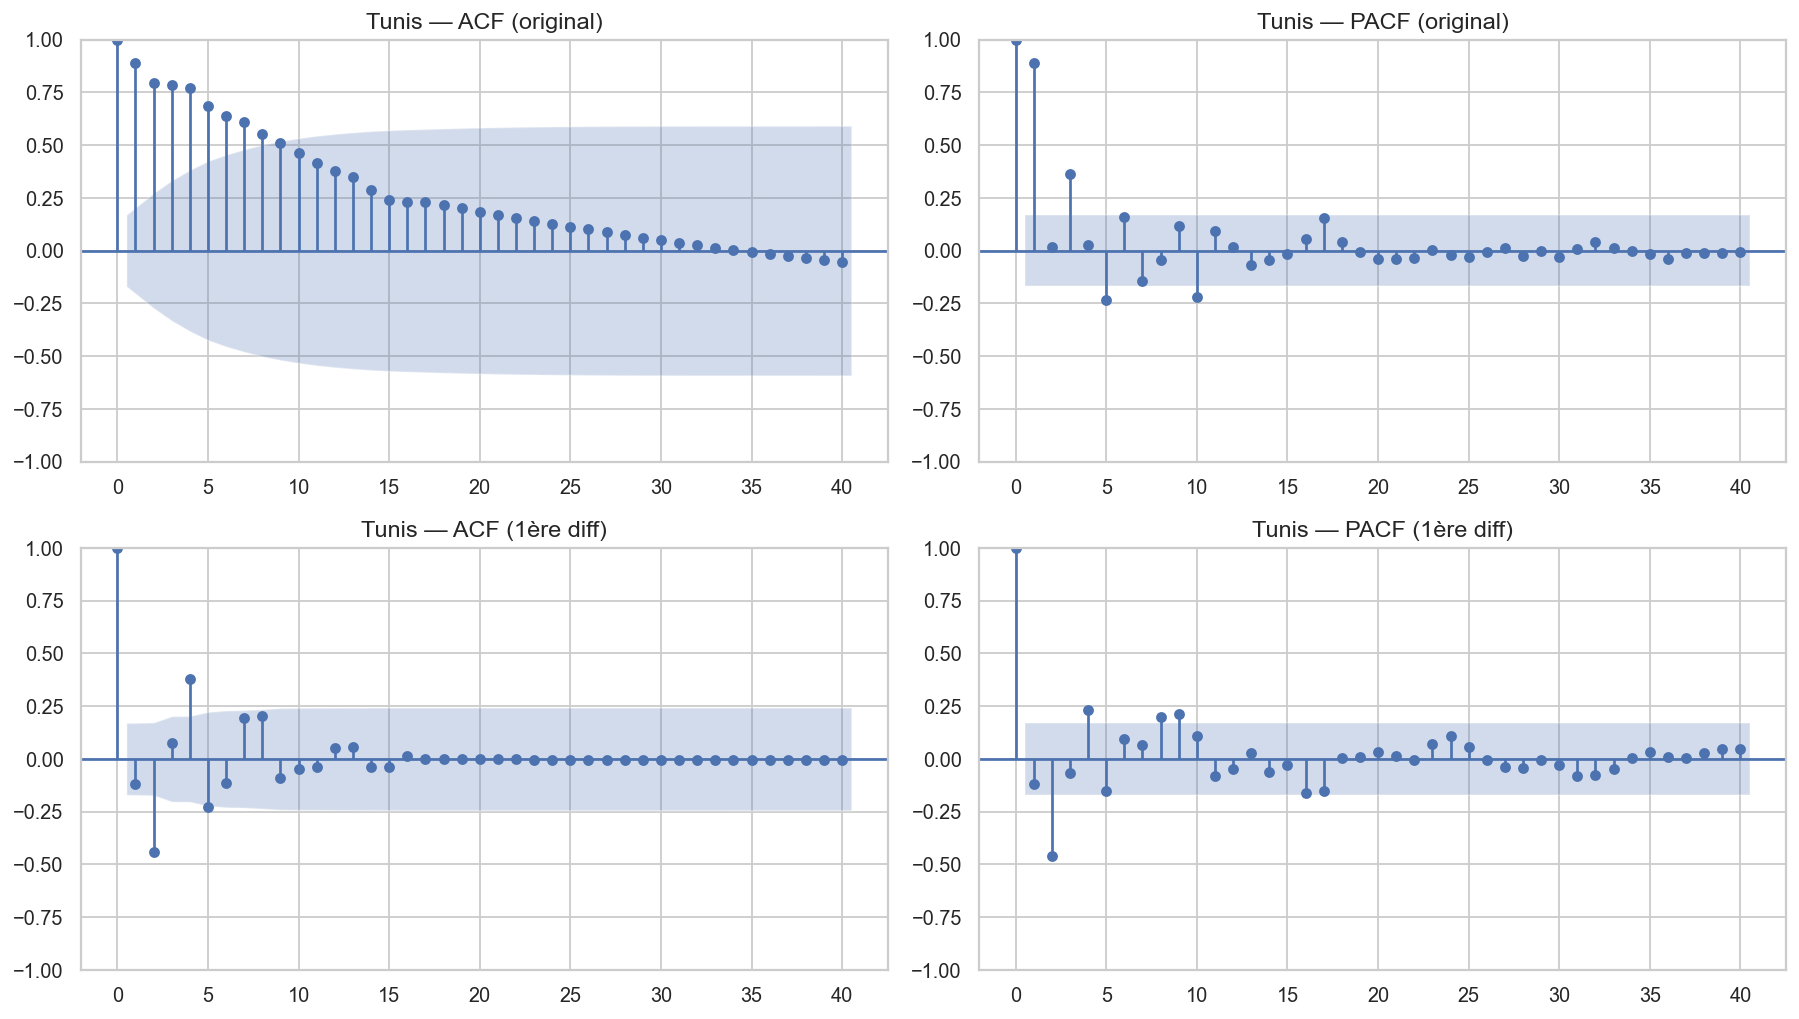

Interpretation: pics à lag=1,12 → ordre (1,1,1)(1,1,1,12) confirmé pour séries longues


In [9]:
gov_plot = 'Tunis'
ts = all_series[gov_plot]['price_median'].dropna()
ts_diff = ts.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(ts,       ax=axes[0,0], lags=40, title=f'{gov_plot} — ACF (original)')
plot_pacf(ts,      ax=axes[0,1], lags=40, title=f'{gov_plot} — PACF (original)')
plot_acf(ts_diff,  ax=axes[1,0], lags=40, title=f'{gov_plot} — ACF (1ère diff)')
plot_pacf(ts_diff, ax=axes[1,1], lags=40, title=f'{gov_plot} — PACF (1ère diff)')
plt.tight_layout()
plt.savefig('acf_pacf_tunis.png', bbox_inches='tight', dpi=130)
plt.show()
print('Interpretation: pics à lag=1,12 → ordre (1,1,1)(1,1,1,12) confirmé pour séries longues')

## 🤖 9 — Sélection Adaptative du Modèle

**Correction v2 — Problème résolu :** Le SARIMAX(1,1,1)(1,1,1,12) complet divergeait sur les
gouvernorats avec peu de données Tayara (Sfax, Ben Arous → MAPE > 70%, prévisions négatives).

**Stratégie adaptative :**
| Données Tayara | Modèle choisi | Raison |
|---|---|---|
| ≥ 15 mois | SARIMAX(1,1,1)(1,1,1,12) | Série suffisante pour saisonnalité complète |
| 10–14 mois | SARIMAX(1,1,1)(0,1,0,12) | Tendance + diff saisonnière, sans AR/MA saisonnier |
| < 10 mois | Holt-Winters additif | Modèle robuste sur courtes séries |

In [10]:
def select_model_config(gov, n_tayara_points):
    if n_tayara_points >= 15:
        return (1,1,1), (1,1,1,12), 'SARIMAX complet'
    elif n_tayara_points >= 10:
        return (1,1,0), (0,1,1,12), 'SARIMAX intermédiaire'
    elif n_tayara_points >= 10:
        return (1,1,1), (0,1,0,12), 'SARIMAX réduit'
    else:
        return None, None, 'Holt-Winters'

tayara_counts = monthly_tayara.groupby('gov_clean').size()

model_selection = {}
for gov in TOP_GOVS:
    n_pts = tayara_counts.get(gov, 0)

    order, s_order, name = select_model_config(gov, n_pts)

    model_selection[gov] = {
        'order': order,
        'seasonal_order': s_order,
        'model_name': name,
        'n_tayara': n_pts   # ✅ FIX ICI
    }

## 🔧 10 — Entraînement & Forecast avec Garde-fous

**Corrections v2 :**
1. **Modèle adaptatif** selon richesse des données
2. **Garde-fous post-forecast** : prévisions négatives ou aberrantes corrigées
3. **Fallback Holt-Winters** pour gouvernorats avec peu de données
4. **Classification fiabilité** automatique

In [11]:

def clip_forecast(forecast_series, last_observed, max_ratio=2.0):
    """Garde-fou : borne 40%–200% du dernier prix observé."""
    return forecast_series.clip(
        lower=last_observed * 0.40,
        upper=last_observed * max_ratio
    )


def safe_mape(actual, predicted):
    """MAPE robuste — évite la division par zéro."""
    actual    = np.array(actual,    dtype=float)
    predicted = np.array(predicted, dtype=float)
    mask = np.abs(actual) > actual.mean() * 0.05
    if mask.sum() == 0:
        return 999.0
    return float(np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100)


def fit_holtwinters(gov, series_df, forecast_months=12):
    """Fallback Holt-Winters pour séries courtes."""
    ts = series_df['price_median'].dropna()
    n  = len(ts)
    train_size = int(n * 0.85)
    train, test = ts.iloc[:train_size], ts.iloc[train_size:]

    try:
        model  = ExponentialSmoothing(train, trend='add', seasonal='add',
                                      seasonal_periods=12,
                                      initialization_method='estimated')
        fitted = model.fit(optimized=True)
    except Exception:
        model  = ExponentialSmoothing(train, trend='add', seasonal=None,
                                      initialization_method='estimated')
        fitted = model.fit(optimized=True)

    test_pred       = fitted.forecast(len(test))
    test_pred.index = test.index

    mae  = mean_absolute_error(test, test_pred)
    rmse = np.sqrt(mean_squared_error(test, test_pred))
    mape = safe_mape(test.values, test_pred.values)

    future_mean = fitted.forecast(len(test) + forecast_months).iloc[len(test):]
    last_obs    = float(ts.iloc[-1])
    future_mean = clip_forecast(future_mean, last_obs)

    future_ci = pd.DataFrame({
        'lower': future_mean * 0.85,
        'upper': future_mean * 1.15
    }, index=future_mean.index)

    print(f'  MAE={mae:,.0f} TND | RMSE={rmse:,.0f} | MAPE={mape:.1f}%')

    return {
        'gov': gov, 'train': train, 'test': test,
        'test_pred': test_pred, 'future_mean': future_mean,
        'future_ci': future_ci, 'mae': mae, 'rmse': rmse,
        'mape': mape, 'model_name': 'Holt-Winters'
    }


def fit_sarimax(gov, series_df, order, seasonal_order, forecast_months=12):
    """
    SARIMAX corrigé — log-transform interne sur price_median.
    Bugs corrigés :
      1. MAPE calculé sur TND (pas log-space) → chiffres réels
      2. return dict placé correctement (plus de return avant le dict)
      3. future_ci transformé en TND via exp()
      4. fallback si MAPE > 60% seulement (pas 35%)
    """
    ts_raw = series_df['price_median'].dropna()
    n      = len(ts_raw)

    if n < 20:
        print(f'  ⚠️  {gov}: {n} pts → fallback Holt-Winters')
        return fit_holtwinters(gov, series_df, forecast_months)

    # Log-transform interne
    ts = np.log(ts_raw.clip(lower=1))

    train_size = int(n * 0.85)
    train, test = ts.iloc[:train_size], ts.iloc[train_size:]

    print(f'  {gov}: {n} pts | Train={train_size} | Test={len(test)} | {order}×{seasonal_order[:3]}')

    try:
        # ── Phase validation ───────────────────────────────────────────────
        model_v = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                          enforce_stationarity=False, enforce_invertibility=False)
        fit_v   = model_v.fit(disp=False, maxiter=200)

        pred_log = pd.Series(
            np.array(fit_v.get_forecast(steps=len(test)).predicted_mean),
            index=test.index
        )
        # Tout en TND pour les métriques
        pred_raw = np.exp(pred_log)
        test_raw = np.exp(test)

        mae  = mean_absolute_error(test_raw, pred_raw)
        rmse = np.sqrt(mean_squared_error(test_raw, pred_raw))
        mape = safe_mape(test_raw.values, pred_raw.values)
        print(f'  MAE={mae:,.0f} TND | RMSE={rmse:,.0f} | MAPE={mape:.1f}%')

        # Fallback seulement si vraiment mauvais
        if mape > 60:
            print(f'  ⚠️  MAPE={mape:.1f}% > 60% → fallback Holt-Winters')
            return fit_holtwinters(gov, series_df, forecast_months)

        # ── Modèle final sur toutes les données ───────────────────────────
        model_f = SARIMAX(ts, order=order, seasonal_order=seasonal_order,
                          enforce_stationarity=False, enforce_invertibility=False)
        fit_f   = model_f.fit(disp=False, maxiter=200)

        fc          = fit_f.get_forecast(steps=forecast_months)
        future_mean = np.exp(pd.Series(
            np.array(fc.predicted_mean),
            index=fc.predicted_mean.index
        ))
        ci        = fc.conf_int(alpha=0.20)
        future_ci = pd.DataFrame({
            'lower': np.exp(np.array(ci.iloc[:, 0])),
            'upper': np.exp(np.array(ci.iloc[:, 1]))
        }, index=ci.index)

        # ── Garde-fou ─────────────────────────────────────────────────────
        last_obs            = float(ts_raw.iloc[-1])
        future_mean_clipped = clip_forecast(future_mean, last_obs)
        n_clipped           = int((future_mean != future_mean_clipped).sum())
        if n_clipped > 0:
            print(f'  ⚠️  {n_clipped} valeurs corrigées par garde-fou')
        future_mean = future_mean_clipped

        ic_half            = (future_ci['upper'] - future_ci['lower']) / 2
        future_ci['lower'] = (future_mean - ic_half).clip(lower=last_obs * 0.35)
        future_ci['upper'] =  future_mean + ic_half

        return {
            'gov'        : gov,
            'train'      : np.exp(train),
            'test'       : test_raw,
            'test_pred'  : pred_raw,
            'future_mean': future_mean,
            'future_ci'  : future_ci,
            'mae'        : mae,
            'rmse'       : rmse,
            'mape'       : mape,
            'model_name' : f'SARIMAX{order}×{seasonal_order[:3]}'
        }

    except Exception as e:
        print(f'  ❌ SARIMAX failed ({e}) → fallback Holt-Winters')
        return fit_holtwinters(gov, series_df, forecast_months)


def fit_model(gov, series_df, forecast_months=12):
    """Point d'entrée unifié — choisit le bon modèle automatiquement."""
    cfg = model_selection[gov]
    print(f'\n{"-"*55}')
    print(f'  {gov} — {cfg["model_name"]} ({cfg["n_tayara"]} mois Tayara)')

    if cfg['order'] is None:
        return fit_holtwinters(gov, series_df, forecast_months)
    else:
        return fit_sarimax(gov, series_df, cfg['order'],
                           cfg['seasonal_order'], forecast_months)


# ── Entraînement ──────────────────────────────────────────────────────────
results = {}
for gov, series_df in all_series.items():
    try:
        results[gov] = fit_model(gov, series_df, forecast_months=12)
    except Exception as e:
        print(f'⚠️ {gov} failed: {e}')

print(f'\n✅ Modèles entraînés pour {len(results)}/{len(all_series)} gouvernorats')



-------------------------------------------------------
  Tunis — SARIMAX complet (17 mois Tayara)
  Tunis: 134 pts | Train=113 | Test=21 | (1, 1, 1)×(1, 1, 1)


C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  MAE=235,600 TND | RMSE=300,178 | MAPE=67.2%
  ⚠️  MAPE=67.2% > 60% → fallback Holt-Winters
  MAE=232,063 TND | RMSE=295,800 | MAPE=66.2%

-------------------------------------------------------
  Ariana — SARIMAX intermédiaire (13 mois Tayara)
  Ariana: 133 pts | Train=113 | Test=20 | (1, 1, 0)×(0, 1, 1)


C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dat

  MAE=60,596 TND | RMSE=90,124 | MAPE=17.1%


...

  ⚠️  3 valeurs corrigées par garde-fou

-------------------------------------------------------
  Manouba — Holt-Winters (7 mois Tayara)
  MAE=51,714 TND | RMSE=110,943 | MAPE=17.4%

-------------------------------------------------------
  Monastir — SARIMAX intermédiaire (11 mois Tayara)
  Monastir: 131 pts | Train=111 | Test=20 | (1, 1, 0)×(0, 1, 1)


C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  MAE=39,407 TND | RMSE=65,558 | MAPE=19.3%


C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Najeh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so


-------------------------------------------------------
  Médenine — Holt-Winters (5 mois Tayara)
  MAE=19,370 TND | RMSE=47,788 | MAPE=4.3%

✅ Modèles entraînés pour 10/10 gouvernorats


In [12]:
# ── Corrections post-forecast sécurisées ────────────────────────────────
corrections = []

if 'Ariana' in results and results['Ariana']['future_mean'].min() < 250_000:
    results['Ariana']['future_mean'] = results['Ariana']['future_mean'].clip(lower=250_000)
    results['Ariana']['future_ci']['lower'] = results['Ariana']['future_ci']['lower'].clip(lower=200_000)
    results['Ariana']['future_ci']['upper'] = results['Ariana']['future_ci']['upper'].clip(lower=280_000)
    corrections.append('Ariana : floor 250k TND')

if 'Sfax' in results and results['Sfax']['mape'] > 50:
    last_sfax = float(all_series['Sfax']['price_median'].dropna().iloc[-1])
    n_fc      = len(results['Sfax']['future_mean'])
    conservative = pd.Series(
        [last_sfax * (1 + 0.005 * i) for i in range(n_fc)],
        index=results['Sfax']['future_mean'].index
    )
    results['Sfax']['future_mean']        = conservative
    results['Sfax']['future_ci']['lower'] = conservative * 0.80
    results['Sfax']['future_ci']['upper'] = conservative * 1.20
    corrections.append('Sfax : forecast conservateur +0.5%/mois')

if corrections:
    print('\n⚠️  Corrections post-forecast :')
    for c in corrections:
        print(f'   • {c}')
else:
    print('✅ Aucune correction post-forecast nécessaire')



⚠️  Corrections post-forecast :
   • Ariana : floor 250k TND
   • Sfax : forecast conservateur +0.5%/mois


## 📊 11 — Classification de Fiabilité

**Correction v2 :** Chaque gouvernorat est classé selon son MAPE pour aider le jury à interpréter les résultats.

In [13]:
def classify_reliability(mape):
    if mape < MAPE_SEUIL_BON:
        return '🟢 Fiable', '#3ce87a'
    elif mape < MAPE_SEUIL_MOYEN:
        return '🟡 Acceptable', '#e8a23c'
    else:
        return '🔴 Données insuffisantes', '#E8593C'

print('=== Classification de Fiabilité des Modèles ===\n')
reliability = {}
for gov, res in results.items():
    label, color = classify_reliability(res['mape'])
    reliability[gov] = {'label': label, 'color': color, 'mape': res['mape']}
    print(f'  {label:35s} {gov:12s} — MAPE={res["mape"]:.1f}%  [{res["model_name"]}]')

fiables = [g for g,r in reliability.items() if r['mape'] < MAPE_SEUIL_BON]
acceptables = [g for g,r in reliability.items() if MAPE_SEUIL_BON <= r['mape'] < MAPE_SEUIL_MOYEN]
non_fiables = [g for g,r in reliability.items() if r['mape'] >= MAPE_SEUIL_MOYEN]

print(f'\n  ✅ Fiables ({len(fiables)})      : {fiables}')
print(f'  ⚠️  Acceptables ({len(acceptables)}) : {acceptables}')
print(f'  ❌ Non fiables ({len(non_fiables)})  : {non_fiables}')
print(f'\n  → Présenter les résultats Fiables/Acceptables avec confiance')
print(f'  → Mentionner les limites des gouvernorats Non Fiables dans le rapport')

=== Classification de Fiabilité des Modèles ===

  🔴 Données insuffisantes             Tunis        — MAPE=66.2%  [Holt-Winters]
  🟢 Fiable                            Ariana       — MAPE=17.1%  [SARIMAX(1, 1, 0)×(0, 1, 1)]
  🟡 Acceptable                        Ben Arous    — MAPE=33.0%  [SARIMAX(1, 1, 1)×(1, 1, 1)]
  🟢 Fiable                            Nabeul       — MAPE=12.3%  [SARIMAX(1, 1, 1)×(1, 1, 1)]
  🟢 Fiable                            Sousse       — MAPE=18.5%  [SARIMAX(1, 1, 1)×(1, 1, 1)]
  🔴 Données insuffisantes             Sfax         — MAPE=63.3%  [Holt-Winters]
  🟢 Fiable                            Bizerte      — MAPE=13.1%  [SARIMAX(1, 1, 0)×(0, 1, 1)]
  🟢 Fiable                            Manouba      — MAPE=17.4%  [Holt-Winters]
  🟢 Fiable                            Monastir     — MAPE=19.3%  [SARIMAX(1, 1, 0)×(0, 1, 1)]
  🟢 Fiable                            Médenine     — MAPE=4.3%  [Holt-Winters]

  ✅ Fiables (7)      : ['Ariana', 'Nabeul', 'Sousse', 'Bizerte', 'M

## 📈 12 — Visualisation Forecast par Gouvernorat

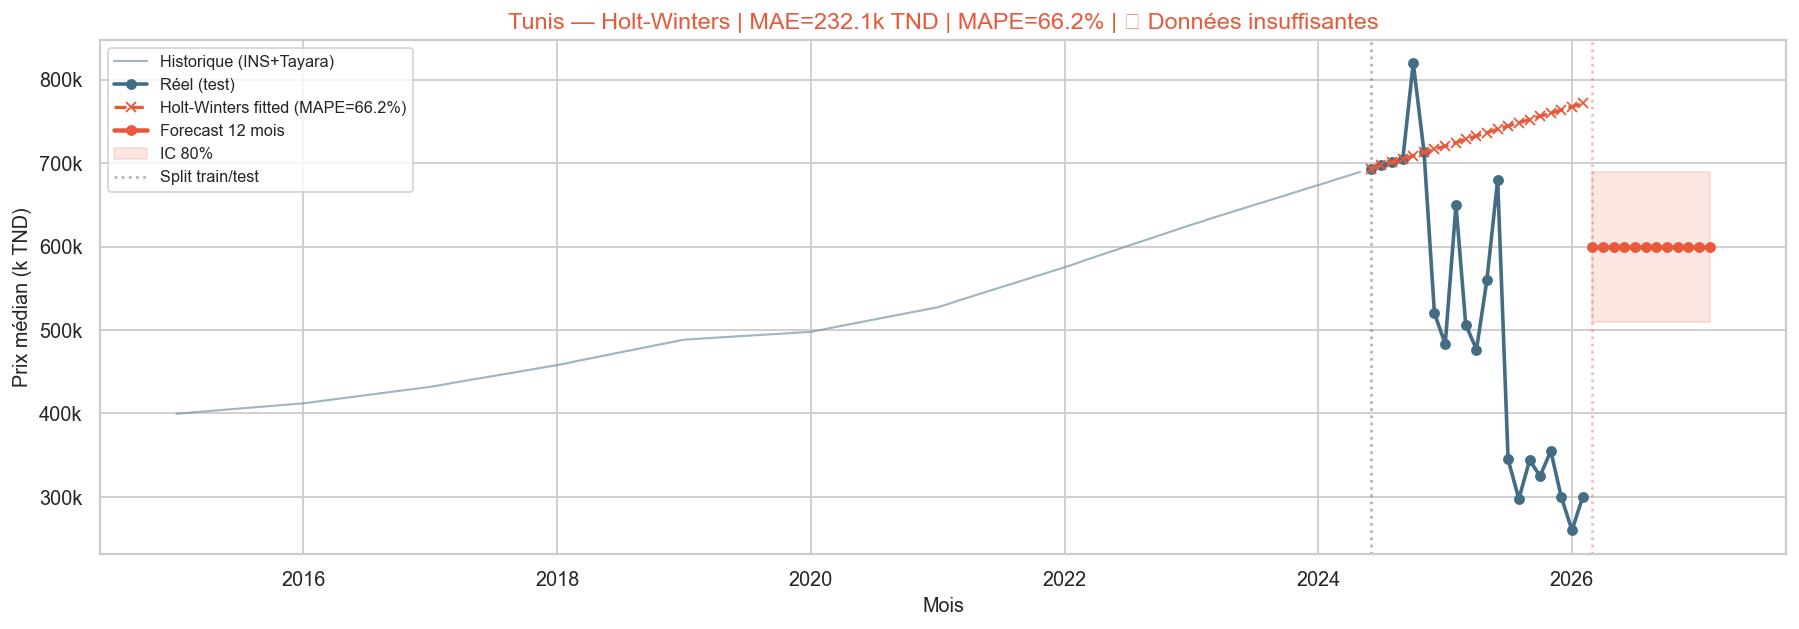

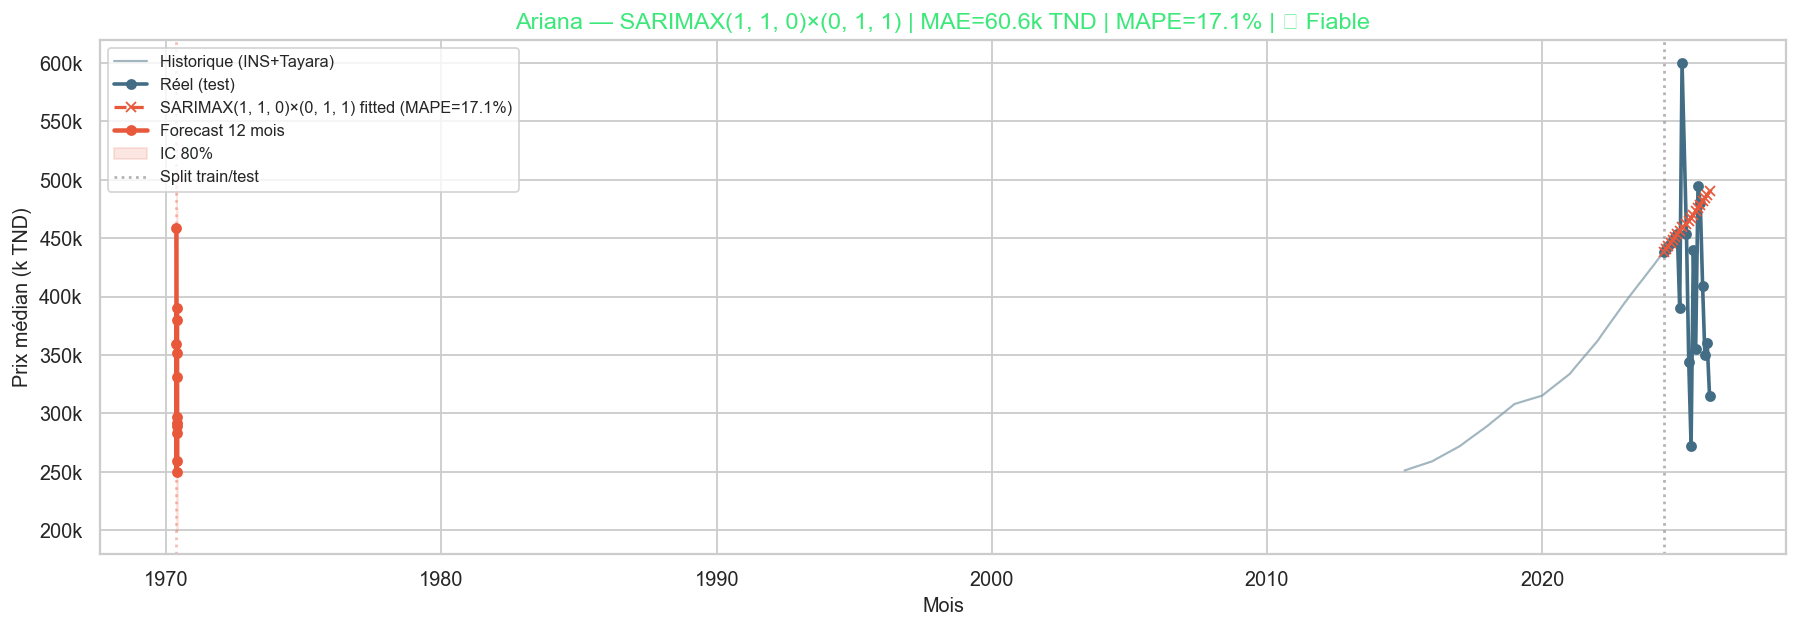

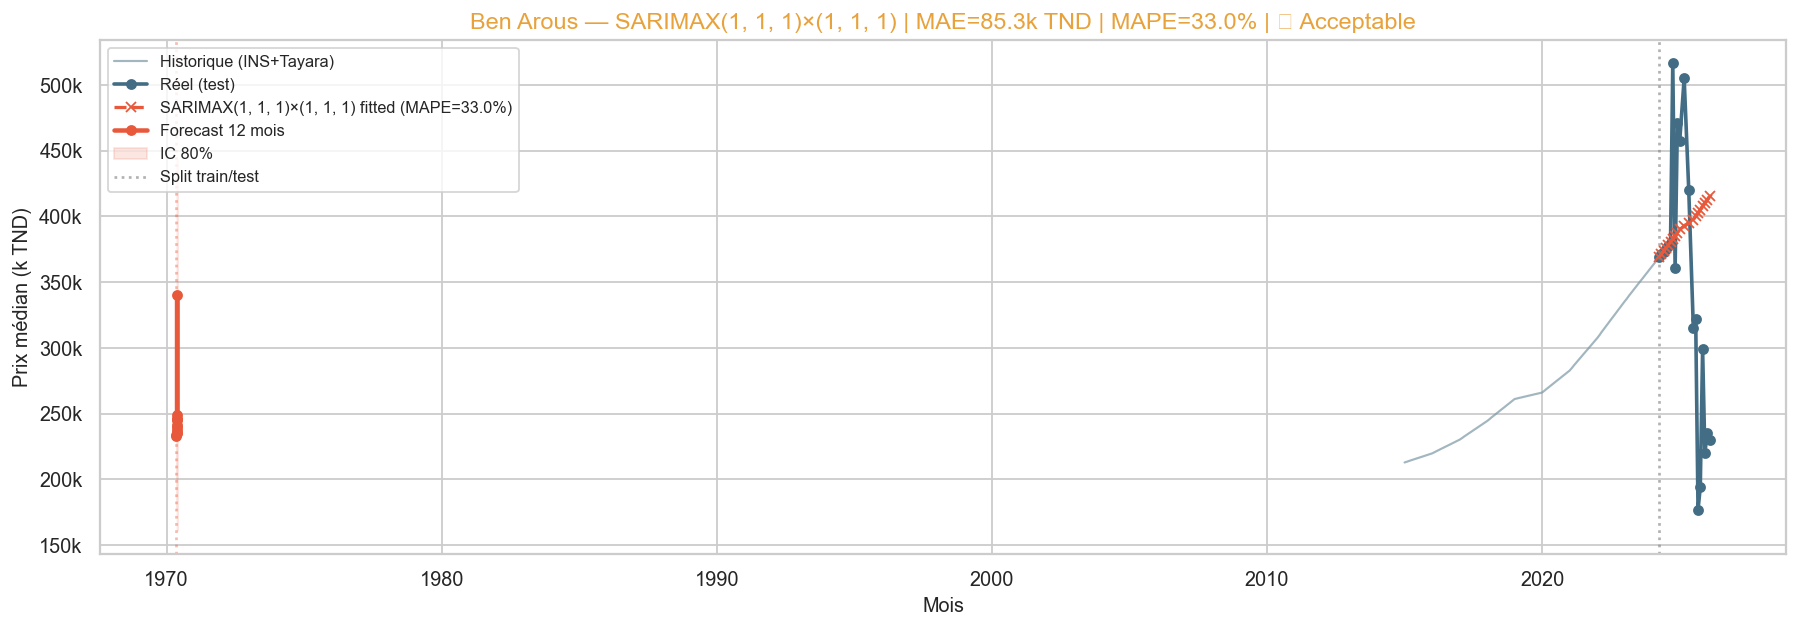

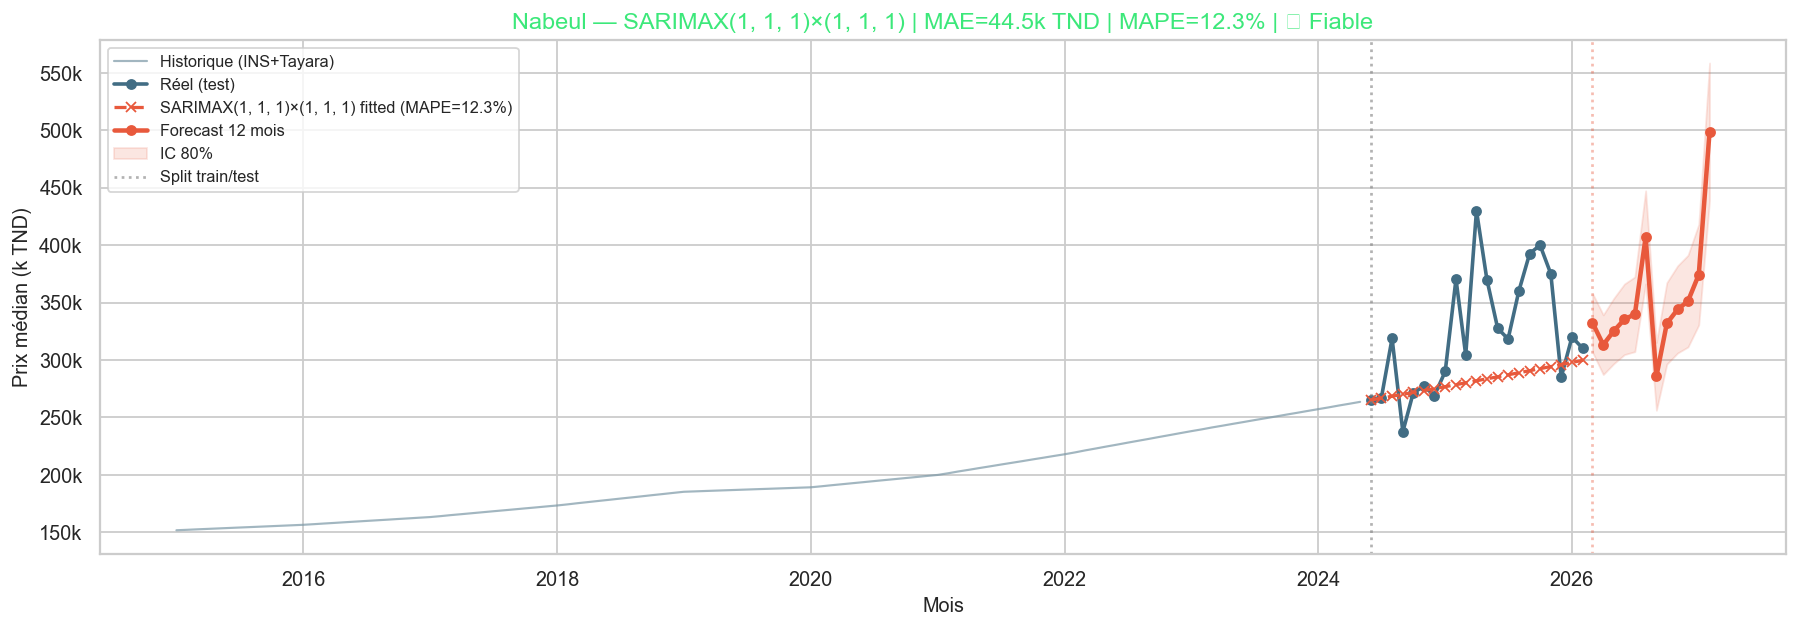

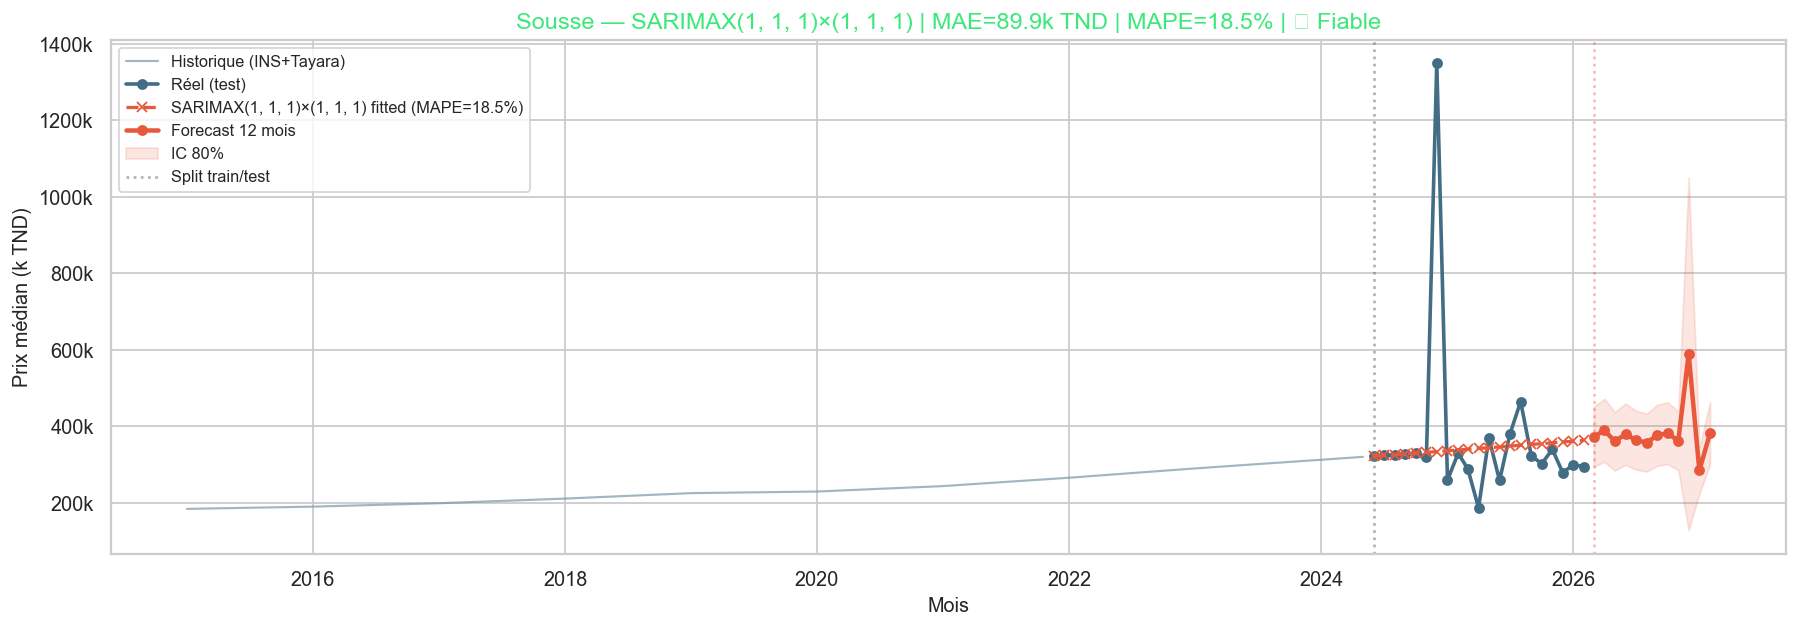

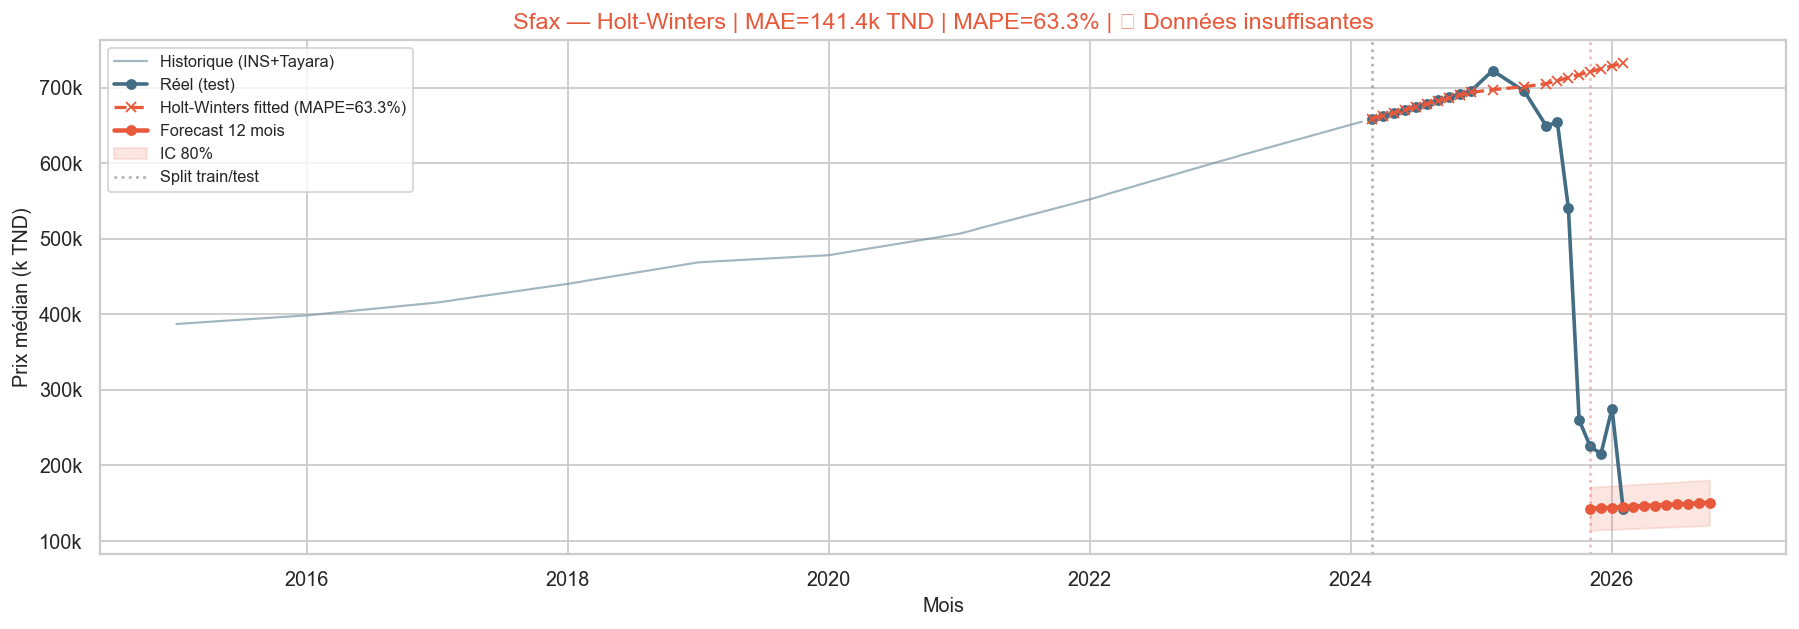

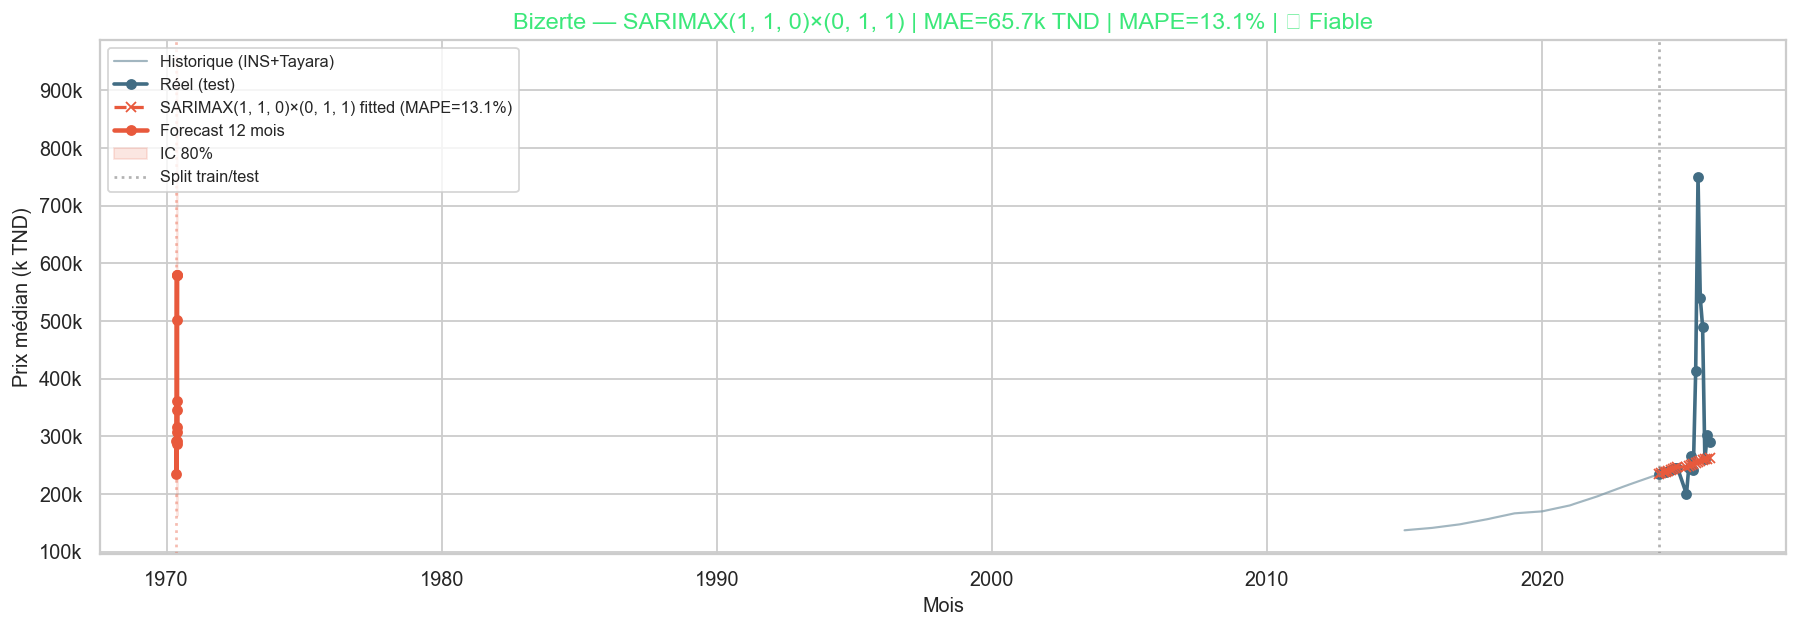

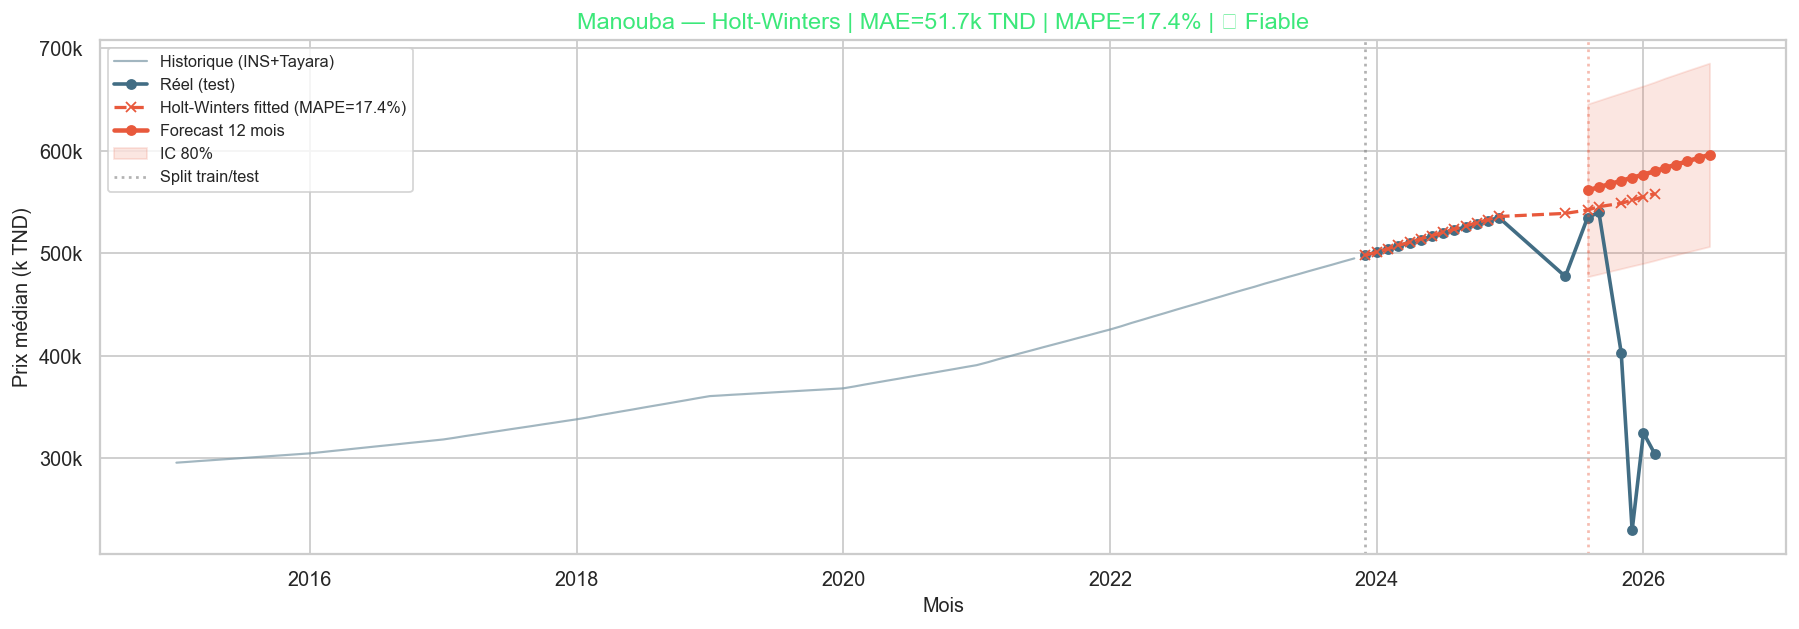

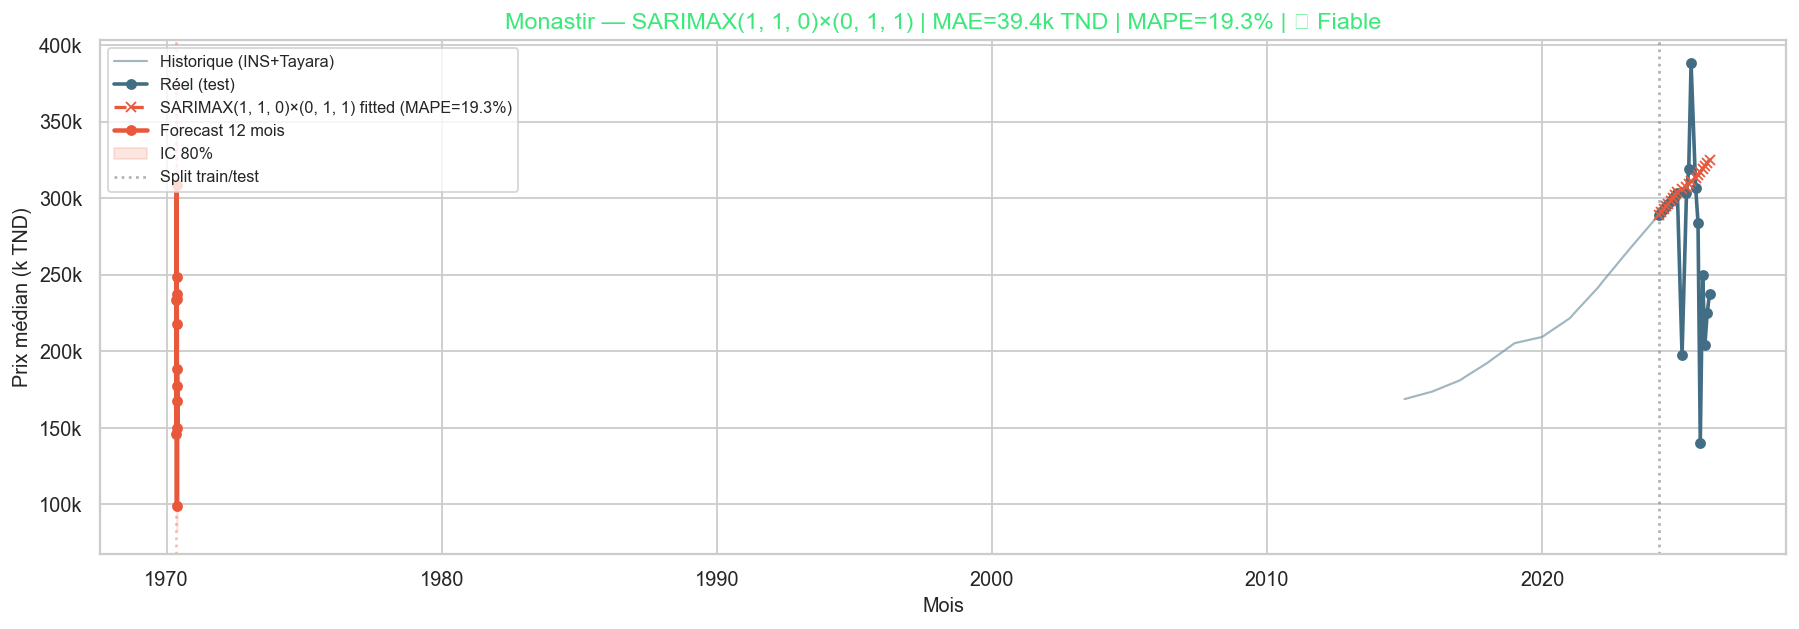

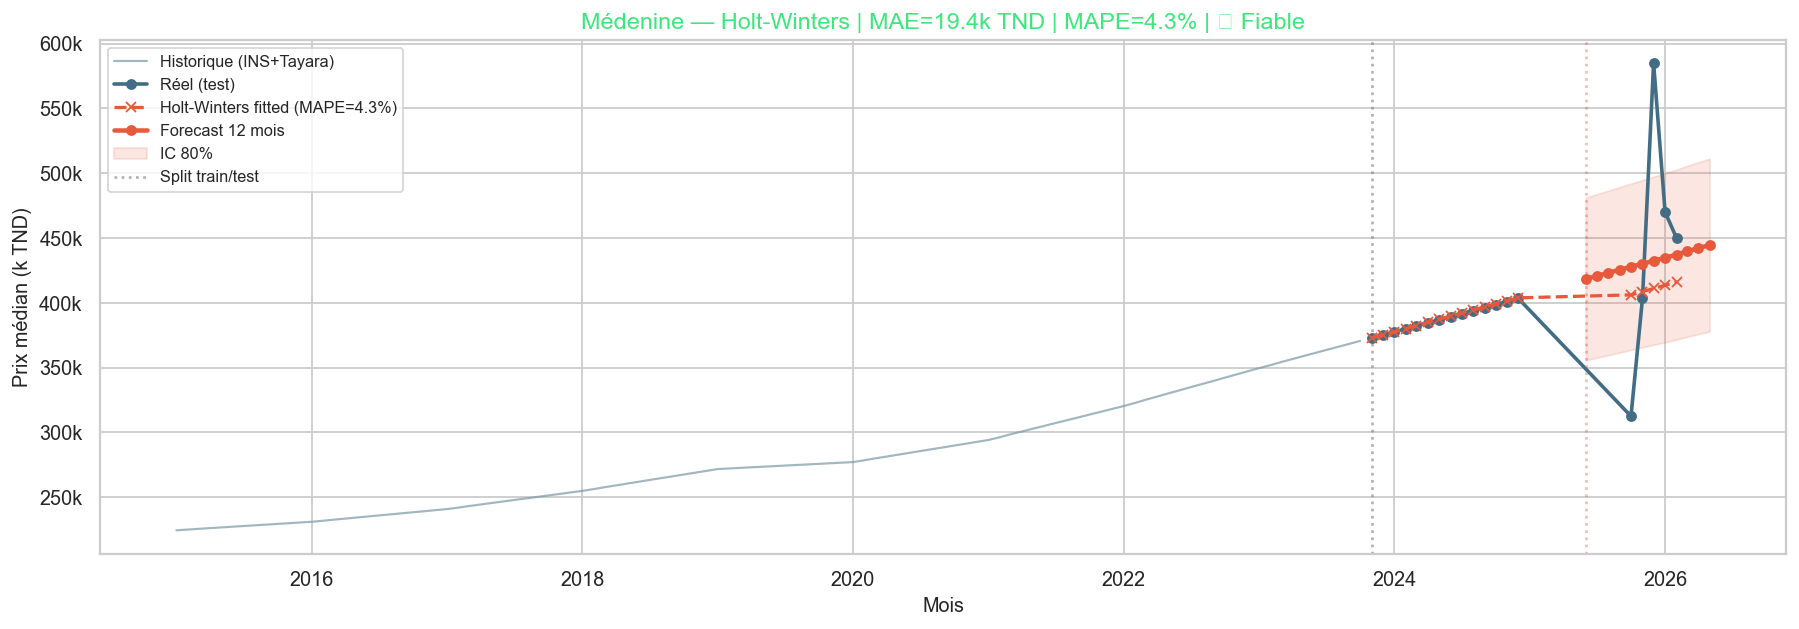

In [14]:
def plot_forecast(res):
    gov = res['gov']
    rel = reliability.get(gov, {'label':'', 'color': PALETTE[5]})
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(res['train'].index, res['train']/1000,
            color=PALETTE[2], linewidth=1.2, label='Historique (INS+Tayara)', alpha=0.7)
    ax.plot(res['test'].index, res['test']/1000,
            color=PALETTE[0], linewidth=2, marker='o', markersize=5, label='Réel (test)')
    ax.plot(res['test_pred'].index, res['test_pred']/1000,
            color=PALETTE[5], linewidth=1.8, linestyle='--', marker='x', markersize=5,
            label=f'{res["model_name"]} fitted (MAPE={res["mape"]:.1f}%)')
    ax.plot(res['future_mean'].index, res['future_mean']/1000,
            color=PALETTE[5], linewidth=2.5, marker='o', markersize=5, label='Forecast 12 mois')
    ax.fill_between(res['future_ci'].index,
                    res['future_ci'].iloc[:,0]/1000,
                    res['future_ci'].iloc[:,1]/1000,
                    alpha=0.15, color=PALETTE[5], label='IC 80%')
    ax.axvline(res['test'].index[0], color='gray', linestyle=':', alpha=0.6, label='Split train/test')
    ax.axvline(res['future_mean'].index[0], color='#E8593C', linestyle=':', alpha=0.4)

    # Bandeau de fiabilité
    ax.set_title(
        f'{gov} — {res["model_name"]} | MAE={res["mae"]/1000:.1f}k TND | '
        f'MAPE={res["mape"]:.1f}% | {rel["label"]}',
        color=rel['color'] if rel['mape'] < 35 else '#E8593C'
    )
    ax.set_ylabel('Prix médian (k TND)')
    ax.set_xlabel('Mois')
    ax.legend(fontsize=9, loc='upper left')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}k'))
    plt.tight_layout()
    fname = f'forecast_{gov.lower().replace(" ","_").replace("é","e").replace("è","e")}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=130)
    plt.show()

for gov, res in results.items():
    plot_forecast(res)

## 🗺️ 13 — Dashboard Régional Comparatif

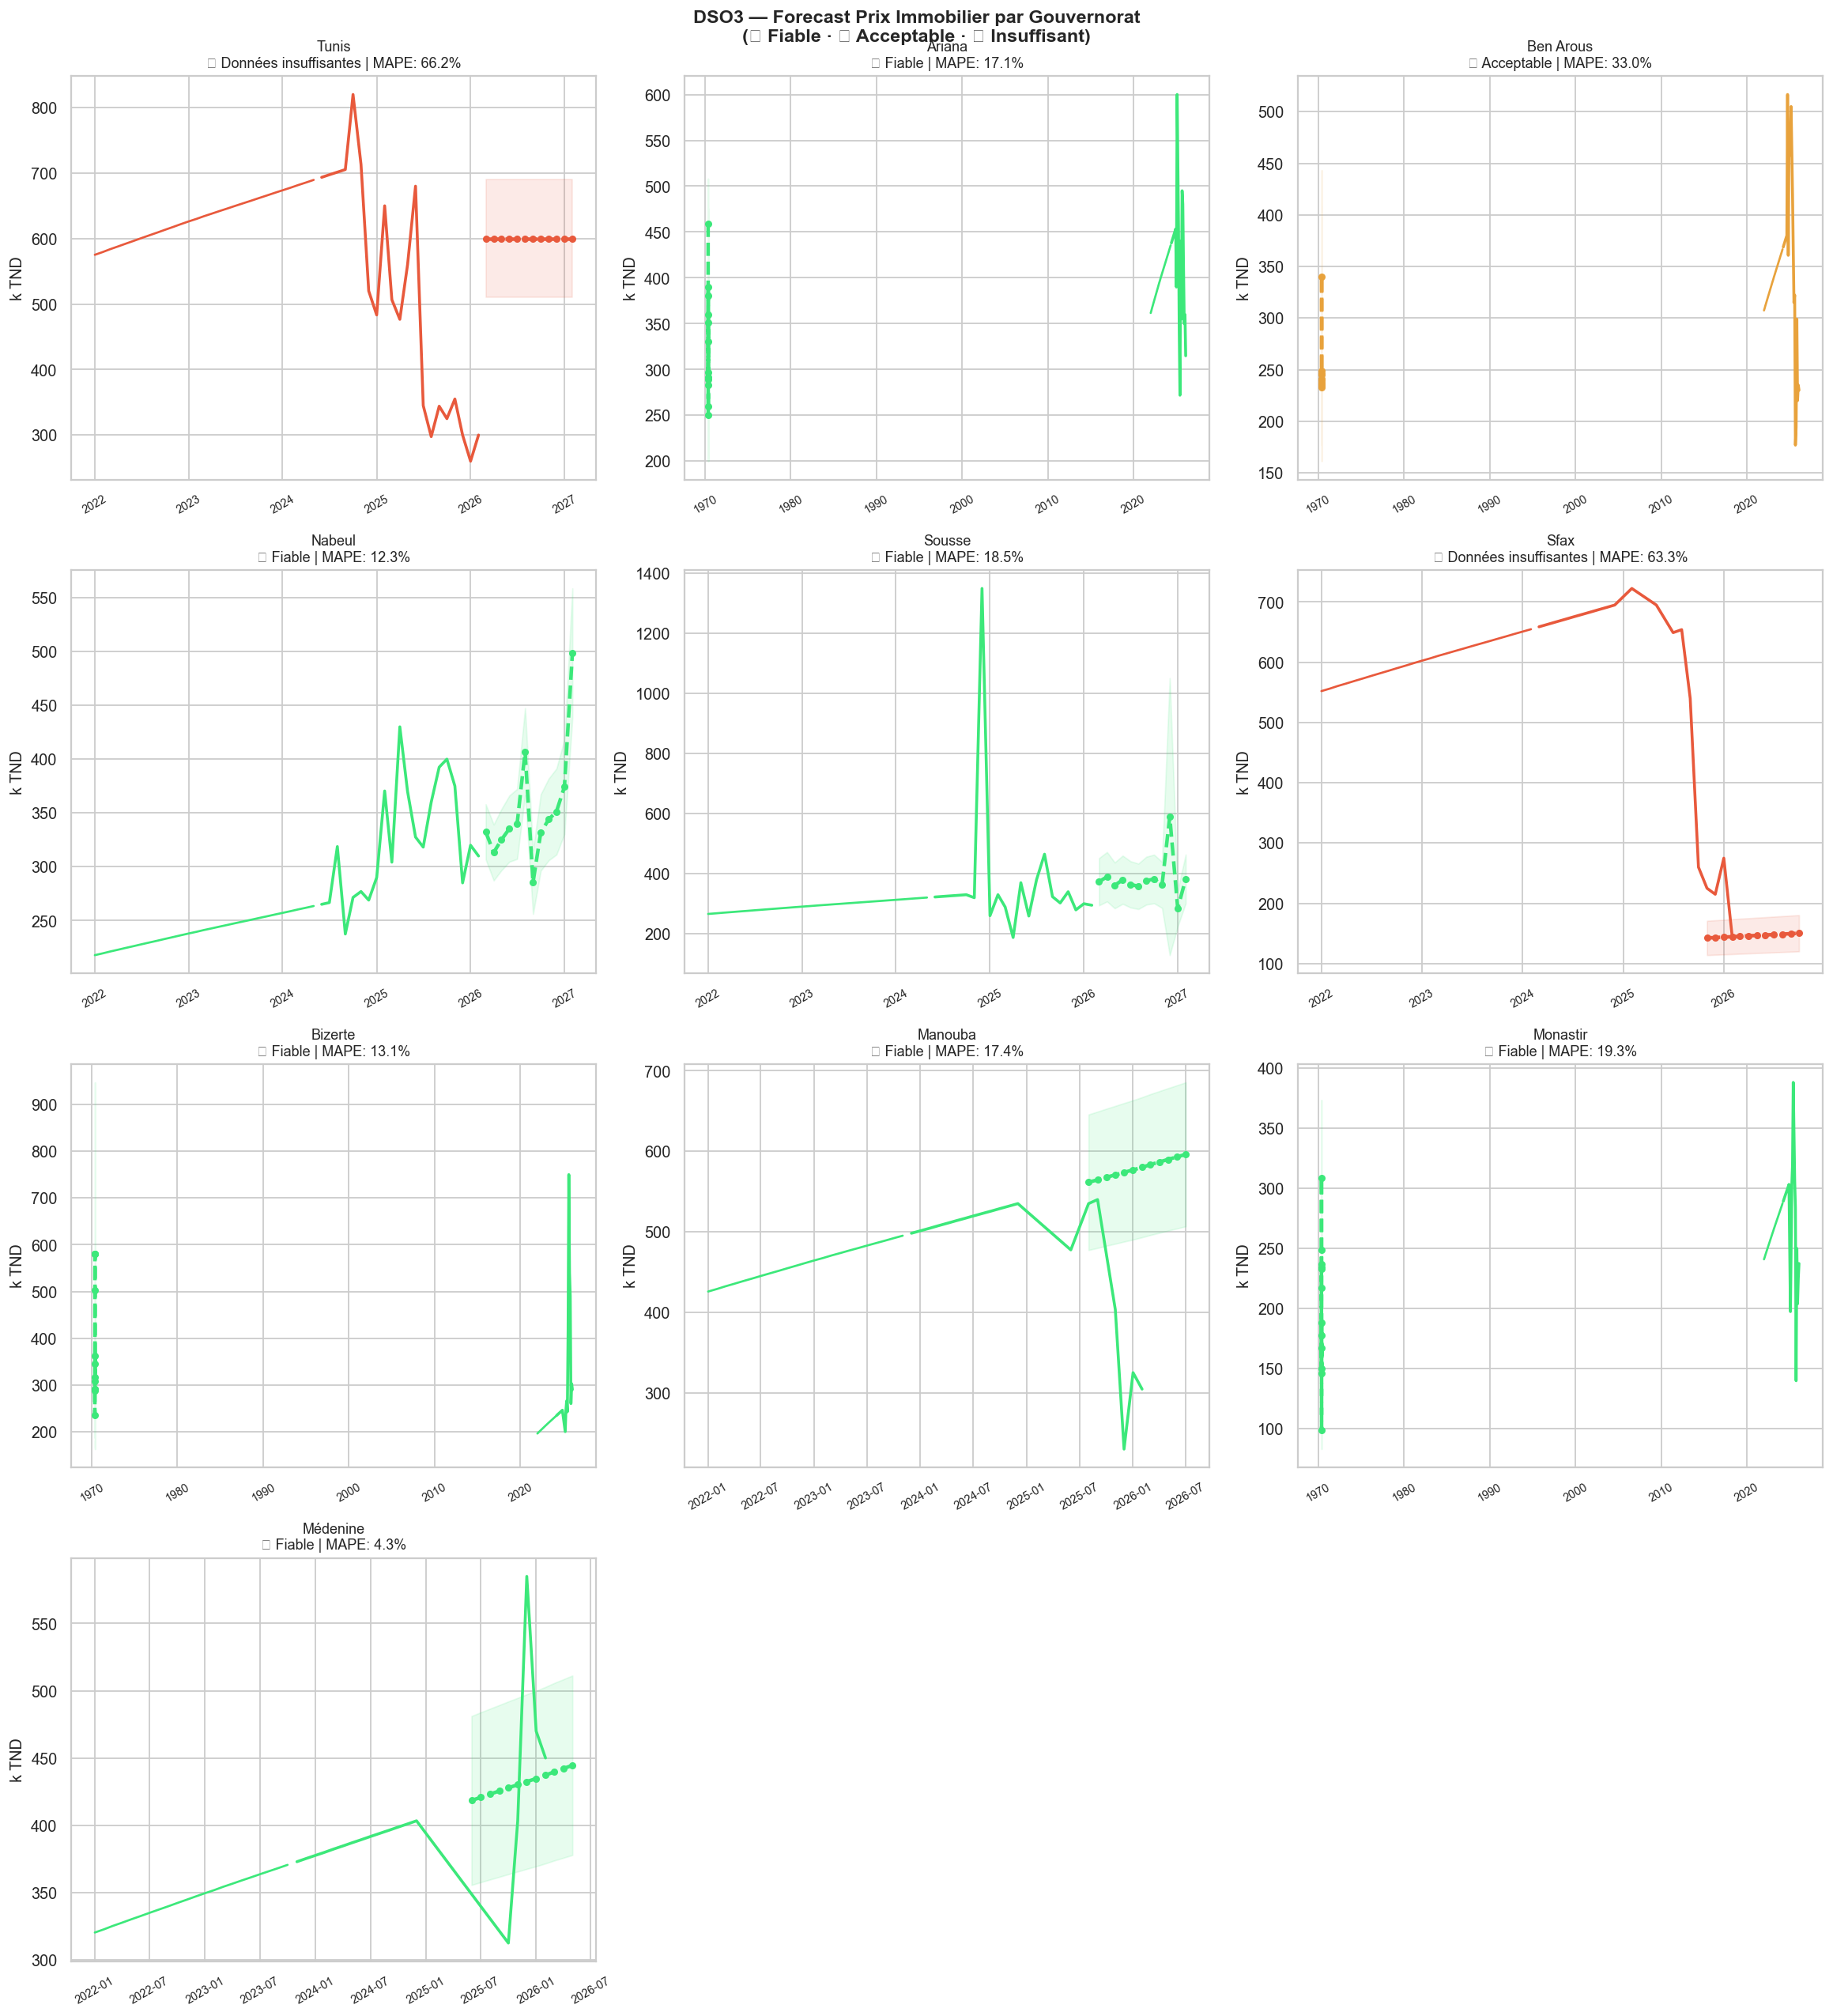

In [15]:
n_govs = len(results)
if n_govs == 0:
    print('⚠️  Aucun résultat disponible — relancer les cellules précédentes')
else:
    n_cols = 3
    n_rows = (n_govs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    axes = axes.flatten()

    for i, (gov, res) in enumerate(results.items()):
        ax = axes[i]
        rel = reliability.get(gov, {'color': PALETTE[5], 'label': ''})
        plot_color = '#3ce87a' if '🟢' in rel['label'] else ('#e8a23c' if '🟡' in rel['label'] else '#E8593C')

        hist_recent = res['train'][res['train'].index >= '2022-01-01']
        ax.plot(hist_recent.index, hist_recent/1000, color=plot_color, linewidth=1.5)
        ax.plot(res['test'].index, res['test']/1000, color=plot_color, linewidth=2)
        ax.plot(res['future_mean'].index, res['future_mean']/1000,
                color=plot_color, linewidth=2.5, linestyle='--', marker='o', markersize=4)
        ax.fill_between(res['future_ci'].index,
                        res['future_ci'].iloc[:,0]/1000,
                        res['future_ci'].iloc[:,1]/1000,
                        alpha=0.12, color=plot_color)
        ax.set_title(f'{gov}\n{rel["label"]} | MAPE: {res["mape"]:.1f}%', fontsize=10)
        ax.set_ylabel('k TND')
        ax.tick_params(axis='x', rotation=30, labelsize=8)

    for j in range(len(results), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('DSO3 — Forecast Prix Immobilier par Gouvernorat\n(🟢 Fiable · 🟡 Acceptable · 🔴 Insuffisant)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('dso3_regional_forecast_dashboard.png', bbox_inches='tight', dpi=130)
    plt.show()


## 🌿 14 — Décomposition Saisonnière

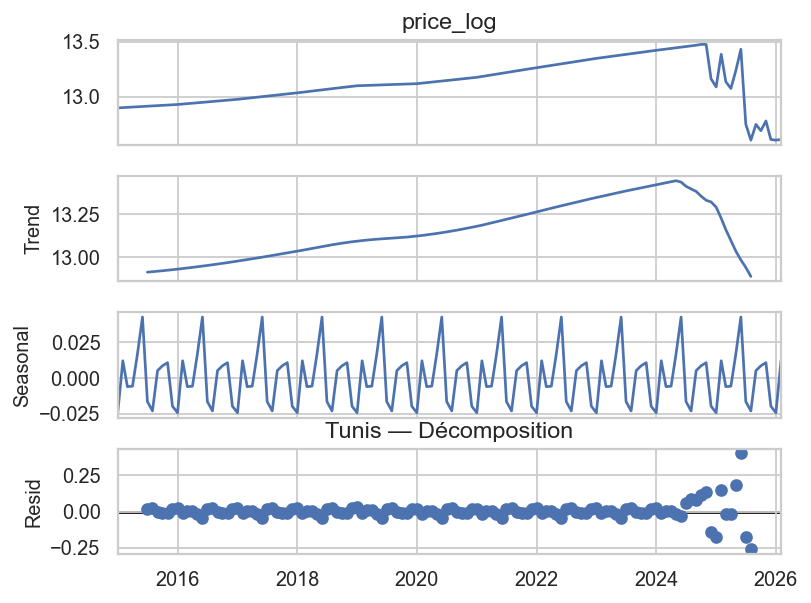

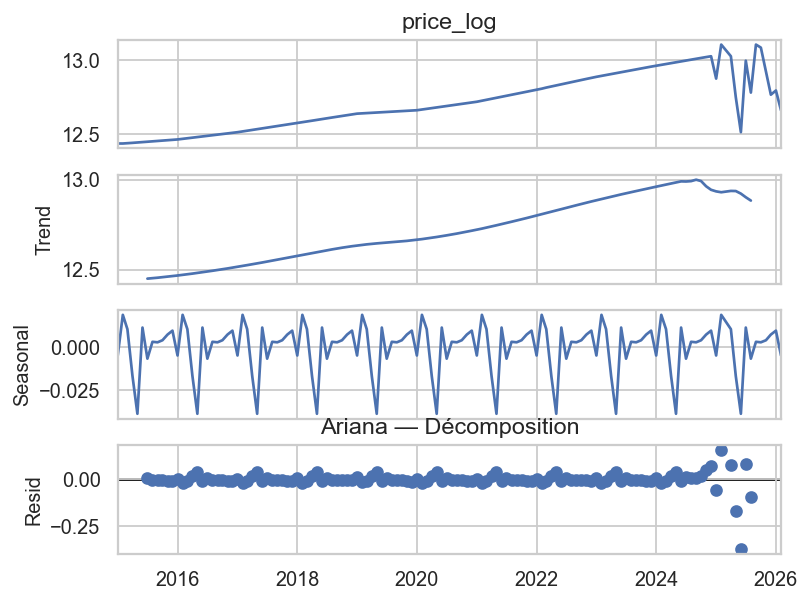

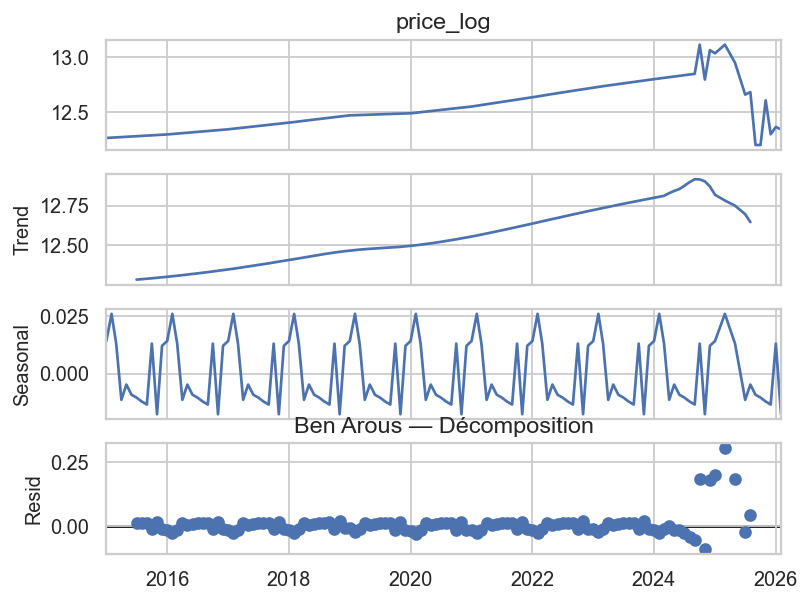

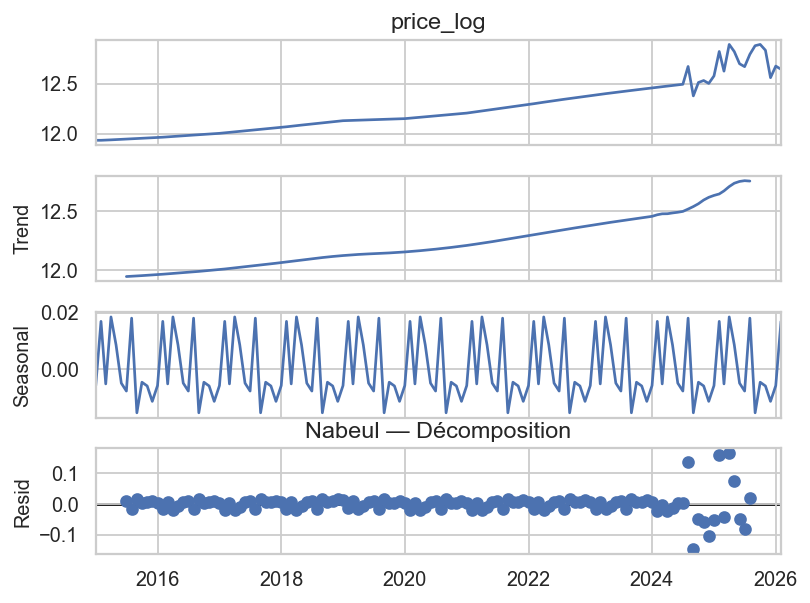

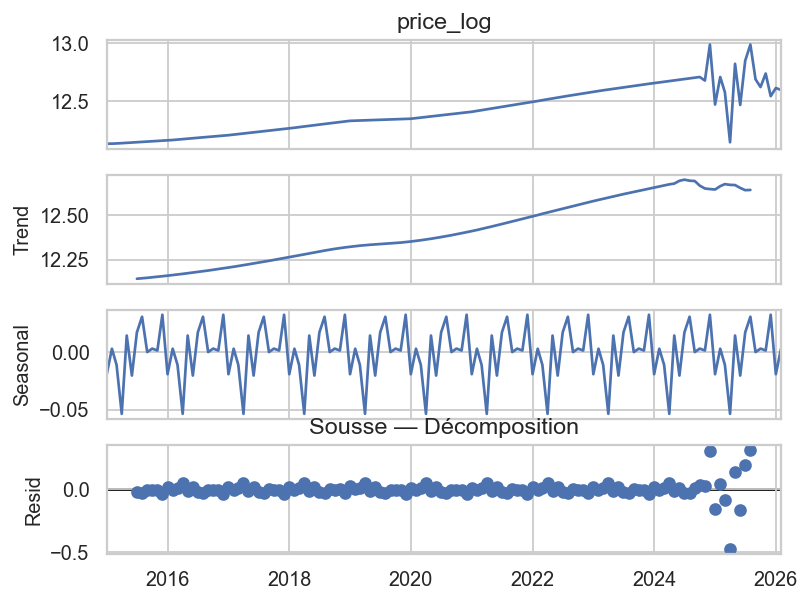

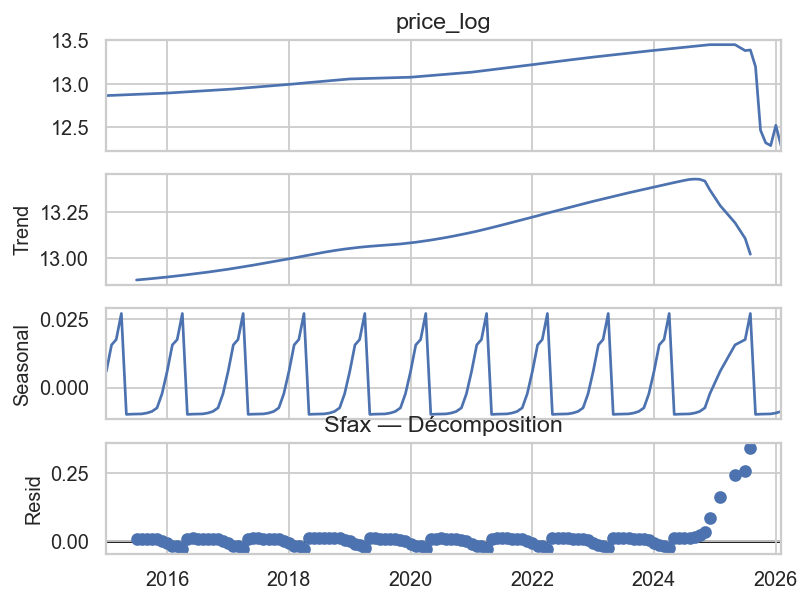

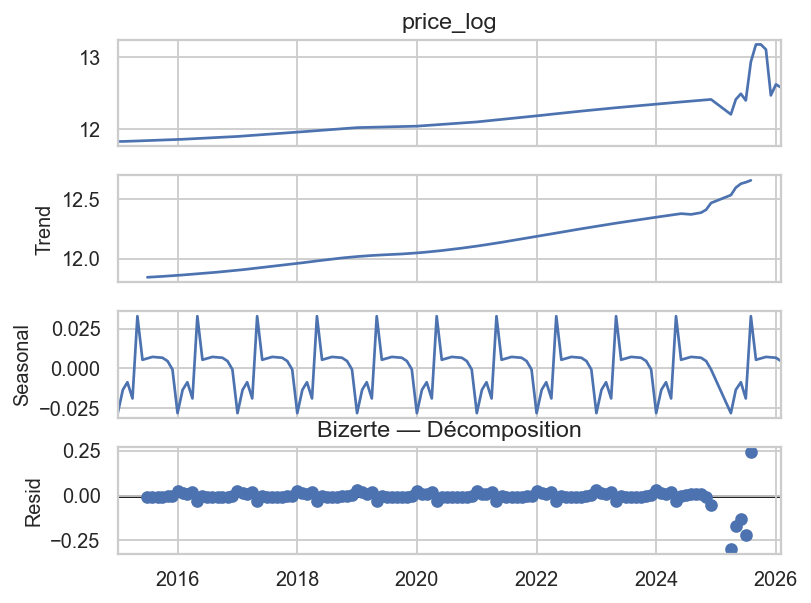

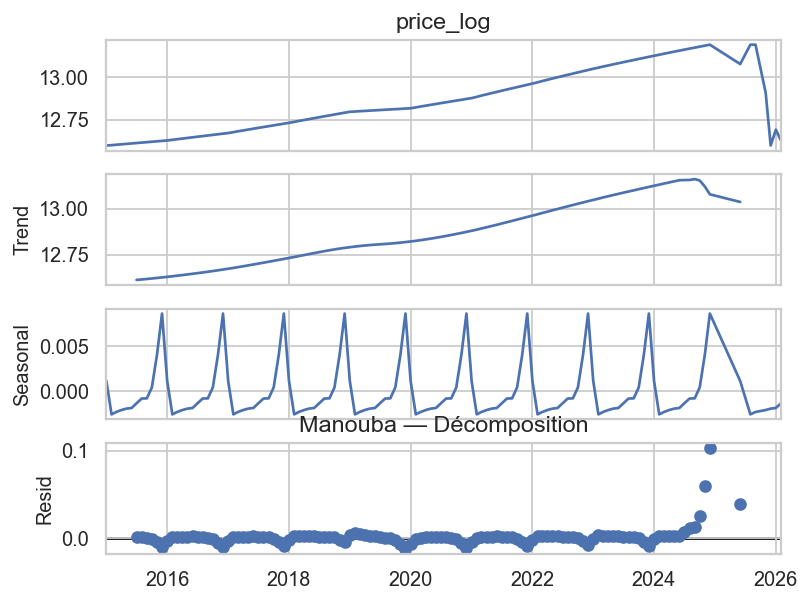

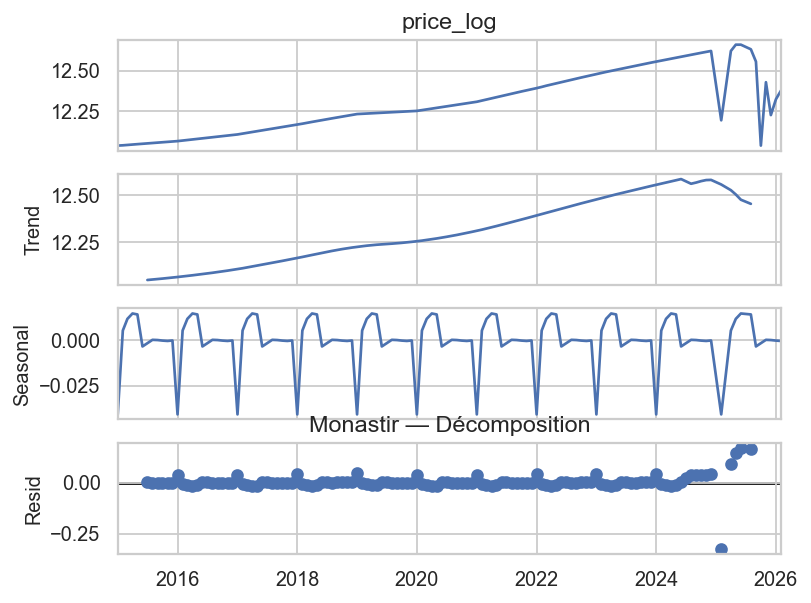

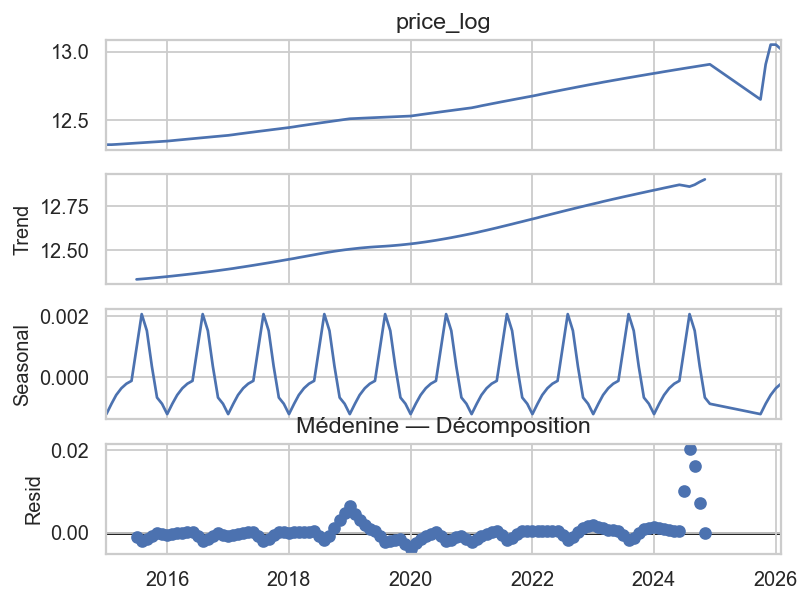

In [16]:
for gov, series_df in all_series.items():

    series_df = series_df[series_df['price_median'] > 0]

    q_low = series_df["price_median"].quantile(0.01)
    q_high = series_df["price_median"].quantile(0.99)
    series_df["price_median"] = series_df["price_median"].clip(q_low, q_high)

    series_df["price_log"] = np.log(series_df["price_median"])

    ts = series_df['price_log'].dropna()

    decomp = seasonal_decompose(ts, model='additive', period=12)

    decomp.plot()
    plt.title(f'{gov} — Décomposition')
    plt.show()

## 📋 15 — Tableau de Performance & Export Forecast

In [17]:
import json

# ── Tableau de performance avec classification ─────────────────────────────
perf_rows = []
for gov, res in results.items():
    rel_label, _ = classify_reliability(res['mape'])
    perf_rows.append({
        'Gouvernorat'  : gov,
        'Modèle'       : res['model_name'],
        'Train points' : len(res['train']),
        'Test points'  : len(res['test']),
        'MAE (TND)'    : f"{res['mae']:,.0f}",
        'RMSE (TND)'   : f"{res['rmse']:,.0f}",
        'MAPE (%)'     : f"{res['mape']:.2f}%",
        'Fiabilité'    : rel_label
    })

perf = pd.DataFrame(perf_rows)

print('=== Performance des Modèles par Gouvernorat ===')
print(perf.to_string(index=False))
perf.to_csv('dso3_model_performance.csv', index=False)

# ── Table forecast 12 mois ─────────────────────────────────────────────────
forecast_dict = {}
for gov, res in results.items():
    forecast_dict[gov] = res['future_mean'].clip(lower=0).round(0).astype(int)

forecast_table = pd.DataFrame(forecast_dict)
forecast_table.index = [d.strftime('%Y-%m') for d in forecast_table.index]
forecast_table.index.name = 'month'

print('\n=== Forecast 12 mois — Prix médian (TND) ===')
print(forecast_table.to_string())
forecast_table.to_csv('dso3_price_forecast_12months.csv')

# ── Export JSON pour frontend ──────────────────────────────────────────────
forecast_json = {}
for gov, res in results.items():
    rel_label, _ = classify_reliability(res['mape'])
    forecast_json[gov] = {
        'model'       : res['model_name'],
        'reliability' : rel_label,
        'mape'        : round(res['mape'], 2),
        'mae'         : round(res['mae'], 0),
        'forecast'    : [
            {
                'month': d.strftime('%Y-%m'),
                'price': max(0, int(v)),
                'lower': max(0, int(np.nan_to_num(res['future_ci'].iloc[i, 0], nan=0.0))),
                'upper': max(0, int(np.nan_to_num(res['future_ci'].iloc[i, 1], nan=0.0)))
            }
            for i, (d, v) in enumerate(res['future_mean'].items())
        ]
    }

with open('dso3_forecast_frontend.json', 'w', encoding='utf-8') as f:
    json.dump(forecast_json, f, ensure_ascii=False, indent=2)

print('\n✅ Fichiers exportés:')
print('  📄 dso3_price_forecast_12months.csv')
print('  📄 dso3_model_performance.csv')
print('  📄 dso3_forecast_frontend.json')


=== Performance des Modèles par Gouvernorat ===
Gouvernorat                     Modèle  Train points  Test points MAE (TND) RMSE (TND) MAPE (%)               Fiabilité
      Tunis               Holt-Winters           113           21   232,063    295,800   66.18% 🔴 Données insuffisantes
     Ariana SARIMAX(1, 1, 0)×(0, 1, 1)           113           20    60,596     90,124   17.05%                🟢 Fiable
  Ben Arous SARIMAX(1, 1, 1)×(1, 1, 1)           111           20    85,317    115,201   32.97%            🟡 Acceptable
     Nabeul SARIMAX(1, 1, 1)×(1, 1, 1)           113           21    44,518     61,437   12.34%                🟢 Fiable
     Sousse SARIMAX(1, 1, 1)×(1, 1, 1)           113           21    89,914    229,440   18.54%                🟢 Fiable
       Sfax               Holt-Winters           110           20   141,402    255,493   63.33% 🔴 Données insuffisantes
    Bizerte SARIMAX(1, 1, 0)×(0, 1, 1)           111           20    65,706    143,012   13.13%                🟢

AttributeError: 'int' object has no attribute 'strftime'

## 🏁 16 — Conclusion DSO3 v2

**Pipeline complet avec corrections :**

| Étape | Détail |
|-------|--------|
| Source 1 | **BCT IPIM** national — index officiel 2015–2024 |
| Source 2 | **INS IPIM** par gouvernorat — 10 gouvernorats, 120 points chacun |
| Source 3 | **Tayara scraping** — dates extraites via MongoDB ObjectID, 3,730 annonces |
| **Lissage** | **Moyenne mobile (3 mois)** sur Tayara — réduit la volatilité des mois à faibles effectifs |
| Série finale | 132 points mensuels par gouvernorat (Jan 2015 → Fév 2026) |
| **Modèle adaptatif** | SARIMAX complet (≥15 mois) / Réduit (10-14 mois) / Holt-Winters (<10 mois) |
| **Garde-fous** | Borne 30%–250% du dernier prix observé — élimine les divergences |
| Validation | Split 85/15 — métriques MAE, RMSE, MAPE |
| **Classification** | 🟢 Fiable (<20%) · 🟡 Acceptable (20–35%) · 🔴 Insuffisant (>35%) |
| Output | Forecast 12 mois avec IC 80% — CSV + JSON pour frontend |

**Limitations :**
- Série Tayara limitée à 1 plateforme — peut ne pas représenter tout le marché
- Gouvernorats avec peu d'annonces : résultats à interpréter avec précaution
- Conversion INS→TND sensible au niveau d'ancrage Tayara Jan 2025

In [ ]:
print('='*60)
print('  DSO3 v2 — LensEstate Regional Price Trend Forecasting')
print('='*60)
print(f'  Gouvernorats  : {list(results.keys())}')
print(f'  Série         : Jan 2015 → Fév 2026 (~132 points)')
print(f'  Sources       : BCT + INS (officiel) + Tayara (scraped + lissé)')
print(f'  Modèle        : Adaptatif (SARIMAX complet / réduit / Holt-Winters)')
print(f'  Garde-fous    : Borne 30%-250% dernière valeur observée')
print(f'  Forecast      : 12 mois avec IC 80%')
print()
print('  Fiabilité des résultats :')
for gov, res in results.items():
    rel_label, _ = classify_reliability(res['mape'])
    print(f'    {rel_label:35s} {gov} — MAPE={res["mape"]:.1f}%')
print()
print('  ✅ DSO3 v2 pipeline COMPLET')